# Machine Translation (English to Vietnamese) under Noisy Conditions

In this notebook, you will learn how to:
1. Preprocess and handle parallel text corpora.
2. Build and train a parameter-efficient attention-based Sequence-to-Sequence model.
3. Evaluate translation quality using the BLEU metric.
4. Develop strategies to make your model robust against noisy data within a strict parameter budget.

---

## Problem description
Machine Translation is a sequence-to-sequence problem mapping a source language to a target language.
Unlike classification, the output sequence length is dynamic and may differ from the input length.
We use special tokens to guide the generation:
* `<pad>`: Padding token to make batch sentences equal in length.
* `<unk>`: Unknown word token.
* `<sos>`: Start of sentence token.
* `<eos>`: End of sentence token.

However, real-world data is rarely clean. In this lab, the noise have been injected into the training dataset. The noise includes missing spaces, garbage words, and inverted grammar. Your ultimate goal in the Lab Exercise is to overcome these noise anomalies and output clean Vietnamese translations.

![](framework.png)

# 1. Imports and global settings

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
!cp /content/drive/MyDrive/Seq2Seq_Translation/en-vi-translation-data.zip .
!unzip en-vi-translation-data.zip -d .
!rm -rf en-vi-translation-data.zip

Archive:  en-vi-translation-data.zip
   creating: ./en-vi-translation-data/
  inflating: ./en-vi-translation-data/test.vi.txt  
  inflating: ./en-vi-translation-data/test_noisy.en.txt  
  inflating: ./en-vi-translation-data/train.vi.txt  
  inflating: ./en-vi-translation-data/train_noisy.en.txt  
  inflating: ./en-vi-translation-data/val.vi.txt  
  inflating: ./en-vi-translation-data/val_noisy.en.txt  


In [3]:
import os
import random
import time
import csv
import gc
import math
import re
import json
import hashlib
import shutil
import subprocess
import sys
import html
import unicodedata
from pathlib import Path
from datetime import datetime, timezone
from dataclasses import dataclass
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None
from nltk.translate.bleu_score import brevity_penalty, closest_ref_length, corpus_bleu, modified_precision
from nltk.translate.chrf_score import corpus_chrf, sentence_chrf

In [4]:
# Reproducibility seed
# Using a fixed seed helps make results more repeatable
SEED = 42

def fix_random_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fix_random_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Setup complete. Using device: {device}")


def count_parameters(model):
    """Count trainable parameters for the active improved-model variant."""
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

Setup complete. Using device: cuda


# 2. Data preparation

We load parallel text files where each line contains a pair of sentences.
The English sentences contain noise, while the Vietnamese sentences are clean.

We will:
1. Clean text (lowercase, retain alphanumeric characters and basic punctuation).
2. Build vocabulary mappings from words to unique integer indices.
3. Convert text sentences into integer sequences with `<sos>` and `<eos>` tokens.
4. Pad sequences to uniform lengths.

In [5]:
def normalize_string(s):
    """Normalize encoding and markup without language-specific denoising."""
    s = unicodedata.normalize("NFC", s)
    for _ in range(2):
        decoded = html.unescape(s)
        if decoded == s:
            break
        s = decoded
    s = s.lower().strip()
    s = re.sub(r"([.!?,;:])", r" \1 ", s)
    s = re.sub(r"\s+", r" ", s)
    return s.strip()


INJECTED_GARBAGE_TOKENS = frozenset({"blah", "kekw", "lmao", "bruh"})


@dataclass(frozen=True)
class ParallelRow:
    """One line-aligned corpus record, retaining its original one-based line number."""
    split: str
    line_number: int
    raw_source: str
    raw_target: str
    source: str
    target: str


def normalize_source_string(s, remove_injected_garbage=False):
    """Normalize English source text and optionally delete confirmed injected junk."""
    normalized = normalize_string(s)
    if remove_injected_garbage:
        garbage_pattern = r"(?<!\w)(?:" + "|".join(
            re.escape(token) for token in sorted(INJECTED_GARBAGE_TOKENS)
        ) + r")(?!\w)"
        normalized = re.sub(garbage_pattern, " ", normalized)
        normalized = re.sub(r"\s+", " ", normalized).strip()
    return normalized


def read_parallel_rows(src_path, trg_path, split, remove_injected_garbage=False):
    """Read equal-length parallel files without losing raw row identity."""
    source_lines = Path(src_path).read_text(encoding="utf-8").splitlines()
    target_lines = Path(trg_path).read_text(encoding="utf-8").splitlines()
    if len(source_lines) != len(target_lines):
        raise ValueError(f"{split} source/target line mismatch: {len(source_lines)} != {len(target_lines)}")
    return [
        ParallelRow(
            split=split,
            line_number=index,
            raw_source=raw_source,
            raw_target=raw_target,
            source=normalize_source_string(raw_source, remove_injected_garbage),
            target=normalize_string(raw_target),
        )
        for index, (raw_source, raw_target) in enumerate(zip(source_lines, target_lines), start=1)
    ]


def read_langs(src_path, trg_path, max_samples=None, remove_injected_garbage=False):
    """Compatibility helper returning non-empty normalized pairs."""
    pairs = [
        (row.source, row.target)
        for row in read_parallel_rows(src_path, trg_path, "unspecified", remove_injected_garbage)
        if row.source and row.target
    ]
    return pairs if max_samples is None else pairs[:max_samples]

In [6]:
# Dataset paths. In Colab, upload either the data directory or the original zip.
def find_data_dir():
    required_file = "train_noisy.en.txt"
    candidates = [Path("data"), Path("en-vi-translation-data")]
    for candidate in candidates:
        if (candidate / required_file).is_file():
            return candidate
    for archive in (Path("en-vi-translation-data.zip"), Path("data.zip")):
        if archive.is_file():
            shutil.unpack_archive(archive, ".")
            for candidate in candidates:
                if (candidate / required_file).is_file():
                    return candidate
    raise FileNotFoundError("Dataset not found. Use ./data, ./en-vi-translation-data, or upload its zip archive.")


DATA_DIR = find_data_dir()
train_src, train_trg = str(DATA_DIR / "train_noisy.en.txt"), str(DATA_DIR / "train.vi.txt")
val_src, val_trg = str(DATA_DIR / "val_noisy.en.txt"), str(DATA_DIR / "val.vi.txt")
test_src, test_trg = str(DATA_DIR / "test_noisy.en.txt"), str(DATA_DIR / "test.vi.txt")

# Only visual inspection uses a subset; improved-model training reads the full split below.
visualization_pairs = read_langs(train_src, train_trg, max_samples=30_000)
print(f"Visualization subset: {len(visualization_pairs)} aligned training pairs")

Visualization subset: 30000 aligned training pairs


# 3. Data visualization

Let's print out some samples from our dataset to check the format and look at the dataset properties.

--- DATA SAMPLES INSPECTION ---
Sample 1:
  [Source]: the greatproblem for reform or transformationis the tyranny of common sense ; things that peoplethink , "well , it can 'tbe done any other way becausethat 's the way it's done . "
  [Target]: vấn đề lớn nhất của việc cải cách hay biến đổi là phá bỏ những lề thói thông thường những thứ mà người ta nghĩ rằng . . " nó là vậy đó , làm sao làm khác đi được "

Sample 2:
  [Source]: myself , why ? and iasked
  [Target]: rồi tôi tự hỏi bản thân mình tại sao ?

Sample 3:
  [Source]: larger than someof theother symphonyhalls . it 's
  [Target]: nó lớn hơn một vài hội trường nhạc giao hưởng .

Sample 4:
  [Source]: they were eatingthe same kinds of foods .
  [Target]: chúng ăn cùng loại thức ăn

Sample 5:
  [Source]: venerable . lmfao itwas
  [Target]: sách thật thiêng liêng .



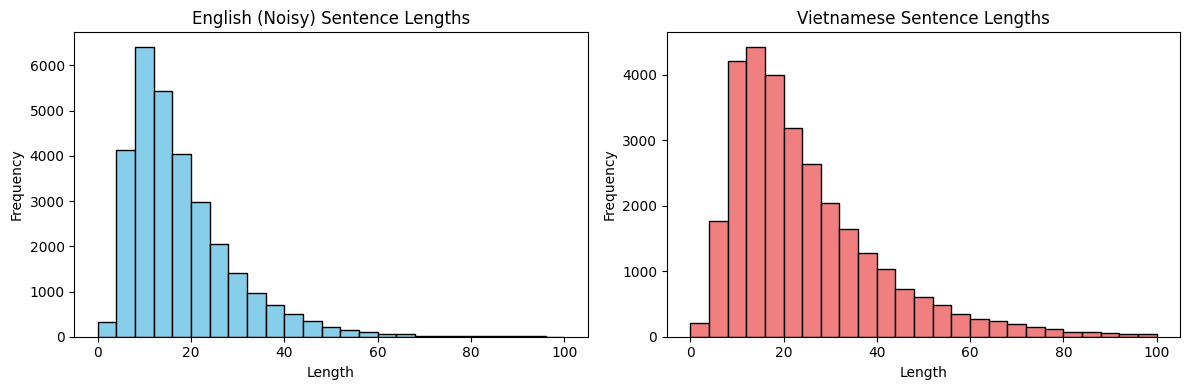

In [7]:
# Print 5 random sentence pairs from training set to inspect
print("--- DATA SAMPLES INSPECTION ---")
for i in range(5):
    idx = random.randint(0, len(visualization_pairs) - 1)
    src_s, trg_s = visualization_pairs[idx]
    print(f'Sample {i+1}:')
    print(f'  [Source]: {src_s}')
    print(f'  [Target]: {trg_s}')
    print()

# Draw sentence length distribution
src_lengths = [len(s.split()) for s, _ in visualization_pairs]
trg_lengths = [len(t.split()) for _, t in visualization_pairs]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(src_lengths, bins=25, range=(0, 100), color='skyblue', edgecolor='black')
plt.title('English (Noisy) Sentence Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(trg_lengths, bins=25, range=(0, 100), color='lightcoral', edgecolor='black')
plt.title('Vietnamese Sentence Lengths')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Lab Exercise: Robust Machine Translation under Budget

## Objective
The baseline model performs poorly on the noisy parallel corpus and consumes a massive amount of parameters due to an inefficient vocabulary. Your task is to implement a robust machine translation pipeline that translates noisy English sentences into clean Vietnamese sentences, **while keeping the model size strictly not greater than 5,000,000 parameters.**

## Tasks

#### **[2.0pts] Denoising & Tokenization**
Design and implement a strategy to make your translation model robust against the noise present in the training data. Feel free to approach this from a data-centric perspective (preprocessing, cleanup), model-centric perspective (advanced network architectures, custom vocabularies), or both.

#### **[4.0pts] Architecture & Parameter Budget**
- Design and train an improved Sequence-to-Sequence translation model. You are encouraged to upgrade the baseline vanilla RNN architecture to more advanced structures (e.g. LSTM, GRU, bidirectional networks, attention mechanisms, or Transformer blocks).
- Prove that your final trainable parameter count (calculated using `count_parameters(model)`) is strictly not greater than 5,000,000 parameters.
- Greedy decoding often suffers from repetitive phrases and suboptimal path selection. Select another decoding strategy for inference.

#### **[1.5pts] Quantitative Analysis**
- Plot the training and validation loss curves over epochs.
- Evaluate the improvement in BLEU scores of your method compared to the baseline.
- Compare BLEU scores and translation outputs when using your decoding strategy versus greedy decoding.

#### **[1.5pts] Qualitative Analysis**
Select 3 noisy sentences from the test set and perform a qualitative analysis:
- If you implemented an Attention mechanism, visualize and analyze the Attention Maps. Discuss whether the model successfully ignores noisy/gibberish words.
- Perform a detailed error analysis comparing the predictions of your model on clean vs. noisy inputs.

#### **[1.0pts] Report & Code Quality**
- Well-structured report following the required format in [`report_requirements.md`](report_requirements.md)
- Clean and reproducible codebase.

#### **[Bonus 1.0pts]**
Outstanding translation quality with under 2,500,000 parameters.

#### **[Penalty]**
- Exceeding the 5,000,000 parameter limit.
- Hardcoding evaluation scores or predictions will result in a 0 for the entire lab.

---

# Improved Model

The following cells implement SentencePiece Unigram tokenization and selectable
BiGRU-attention or compact Transformer variants under the parameter budget.

In [8]:
try:
    import sentencepiece as spm
except ImportError:  # Colab-compatible dependency cell
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentencepiece"])
    import sentencepiece as spm

SRC_VOCAB_SIZE = TRG_VOCAB_SIZE = 4096
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3
MAX_SRC_LEN, MAX_TRG_LEN, MAX_DECODE_LEN = 192, 256, 256
BASE_MODEL_VARIANT = "noise_robust_transformer"
ACTIVE_MODEL_VARIANT = "large_noise_robust_transformer_5x1"

EXPERIMENT_PROFILES = {
    "baseline": {
        "experiment_name": "noise_robust_transformer",
        "remove_injected_garbage": False,
        "model_dropout": 0.0,
        "label_smoothing": 0.0,
    },
    "garbage_cleanup": {
        "experiment_name": "noise_robust_transformer_garbage_cleanup",
        "remove_injected_garbage": True,
        "model_dropout": 0.0,
        "label_smoothing": 0.0,
    },
    "cleanup_regularized": {
        "experiment_name": "noise_robust_transformer_cleanup_regularized",
        "remove_injected_garbage": True,
        "model_dropout": 0.1,
        "label_smoothing": 0.1,
        "use_reviewed_exclusions": False,
    },
    "quality_reviewed": {
        "experiment_name": "noise_robust_transformer_quality_reviewed",
        "remove_injected_garbage": True,
        "model_dropout": 0.1,
        "label_smoothing": 0.1,
        "use_reviewed_exclusions": True,
    },
}
ACTIVE_EXPERIMENT_PROFILE = "cleanup_regularized"
if ACTIVE_EXPERIMENT_PROFILE not in EXPERIMENT_PROFILES:
    raise ValueError(
        f"Unknown ACTIVE_EXPERIMENT_PROFILE: {ACTIVE_EXPERIMENT_PROFILE}. "
        f"Available: {list(EXPERIMENT_PROFILES)}"
    )
EXPERIMENT_PROFILE = EXPERIMENT_PROFILES[ACTIVE_EXPERIMENT_PROFILE]
ACTIVE_EXPERIMENT_NAME = (
    EXPERIMENT_PROFILE["experiment_name"]
    if ACTIVE_MODEL_VARIANT == BASE_MODEL_VARIANT
    else f"{ACTIVE_MODEL_VARIANT}_{ACTIVE_EXPERIMENT_PROFILE}"
)
REMOVE_INJECTED_GARBAGE = EXPERIMENT_PROFILE["remove_injected_garbage"]
MODEL_DROPOUT = EXPERIMENT_PROFILE["model_dropout"]
PROFILE_LABEL_SMOOTHING = EXPERIMENT_PROFILE["label_smoothing"]
USE_REVIEWED_EXCLUSIONS = EXPERIMENT_PROFILE.get("use_reviewed_exclusions", False)


def get_experiment_dir(model_name):
    """Use Google Drive in Colab and a local artifacts directory elsewhere."""
    google_drive = Path("/content/drive/MyDrive")
    output_root = google_drive / "Seq2Seq_Translation" if google_drive.is_dir() else Path("artifacts")
    experiment_dir = output_root / model_name
    experiment_dir.mkdir(parents=True, exist_ok=True)
    return experiment_dir


EXPERIMENT_DIR = get_experiment_dir(ACTIVE_EXPERIMENT_NAME)
TOKENIZER_DIR = EXPERIMENT_DIR / "tokenizers"
DATA_QUALITY_DIR = EXPERIMENT_DIR / "data_quality"
REVIEWED_EXCLUSIONS_PATH = Path("config") / "training_data_exclusions.json"
DATA_QUALITY_SCHEMA_VERSION = 1
AUDIT_THRESHOLDS = {
    "character_length_ratio": 3.0,
    "minimum_character_difference": 50,
    "maximum_source_words": 120,
    "maximum_target_words": 160,
}
print(f"Experiment profile: {ACTIVE_EXPERIMENT_PROFILE}")
print(f"Model artifacts will be saved to: {EXPERIMENT_DIR}")
# Toggle this single flag for the B/C ablation. Validation and test stay clean.
# USE_NOISE_AUGMENTATION = True
# AUGMENT_SENTENCE_PROB = 0.20
USE_NOISE_AUGMENTATION = False
AUGMENT_SENTENCE_PROB = 0.0
AUGMENT_PROBS = {"join": 0.45, "garbage": 0.25, "swap": 0.15, "delete": 0.10, "unk": 0.05}
# Sample English Unigram segmentations during training only. Validation and test remain deterministic.
USE_SUBWORD_REGULARIZATION = True
SUBWORD_SAMPLING_NBEST_SIZE = -1
SUBWORD_SAMPLING_ALPHA = 0.1


def sha256_file(path):
    """Return a content hash used to bind reviewed exclusions to one corpus version."""
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def _row_metrics(row):
    source_words, target_words = len(row.source.split()), len(row.target.split())
    source_characters, target_characters = len(row.source), len(row.target)
    return {
        "source_words": source_words,
        "target_words": target_words,
        "source_characters": source_characters,
        "target_characters": target_characters,
        "character_length_ratio": max(source_characters, target_characters) / max(1, min(source_characters, target_characters)),
        "word_length_ratio": max(source_words, target_words) / max(1, min(source_words, target_words)),
    }


def audit_parallel_data(rows, reserved_sources=(), thresholds=AUDIT_THRESHOLDS):
    """Return deterministic data-quality summary and review-only heuristic flags."""
    reserved_sources = set(reserved_sources)
    pair_counts, targets_by_source = {}, {}
    for row in rows:
        if row.source and row.target:
            pair_counts[(row.source, row.target)] = pair_counts.get((row.source, row.target), 0) + 1
            targets_by_source.setdefault(row.source, set()).add(row.target)
    review_records, reason_counts = [], {}
    for row in rows:
        metrics, reasons = _row_metrics(row), []
        raw_lower = row.raw_source.lower()
        if not row.source:
            reasons.append("blank_source")
        if not row.target:
            reasons.append("blank_target")
        if row.source and row.target and pair_counts[(row.source, row.target)] > 1:
            reasons.append("duplicate_pair")
        if row.source in reserved_sources:
            reasons.append("reserved_split_source_overlap")
        if len(targets_by_source.get(row.source, ())) > 1:
            reasons.append("conflicting_source_targets")
        if any(re.search(r"(?<!\\w)" + re.escape(token) + r"(?!\\w)", raw_lower) for token in INJECTED_GARBAGE_TOKENS):
            reasons.append("injected_garbage")
        if re.search(r"\\d{1,2}\\s*:\\s*\\d{2}.*(?:--|&gt;|>)", row.raw_source + " " + row.raw_target):
            reasons.append("subtitle_timestamp")
        if re.search(r"<[^>]+>|&(?:lt|gt|quot|amp);", row.raw_source + " " + row.raw_target, re.IGNORECASE):
            reasons.append("markup_remnant")
        if metrics["character_length_ratio"] >= thresholds["character_length_ratio"] and abs(metrics["source_characters"] - metrics["target_characters"]) >= thresholds["minimum_character_difference"]:
            reasons.append("extreme_character_length_ratio")
        if metrics["source_words"] > thresholds["maximum_source_words"]:
            reasons.append("extreme_source_length")
        if metrics["target_words"] > thresholds["maximum_target_words"]:
            reasons.append("extreme_target_length")
        for reason in reasons:
            reason_counts[reason] = reason_counts.get(reason, 0) + 1
        if reasons:
            review_records.append({
                "split": row.split, "line_number": row.line_number, "reasons": ";".join(reasons),
                **metrics, "raw_source": row.raw_source, "raw_target": row.raw_target,
                "source": row.source, "target": row.target,
            })
    summary = {
        "schema_version": DATA_QUALITY_SCHEMA_VERSION,
        "total_rows": len(rows), "flagged_rows": len(review_records),
        "reason_counts": reason_counts, "thresholds": thresholds,
    }
    return summary, review_records


def write_data_quality_artifacts(summary, review_records):
    """Persist stable, inspectable audit outputs without modifying corpus files."""
    DATA_QUALITY_DIR.mkdir(parents=True, exist_ok=True)
    (DATA_QUALITY_DIR / "audit_summary.json").write_text(
        json.dumps(summary, ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
    )
    fields = ["split", "line_number", "reasons", "source_words", "target_words", "source_characters", "target_characters", "character_length_ratio", "word_length_ratio", "raw_source", "raw_target", "source", "target"]
    with (DATA_QUALITY_DIR / "heuristic_review.csv").open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        writer.writerows(review_records)


def load_reviewed_exclusions(path, source_path, target_path):
    """Load validated human-approved train row exclusions, never heuristic flags."""
    manifest = json.loads(Path(path).read_text(encoding="utf-8"))
    required = {"schema_version", "train_source_sha256", "train_target_sha256", "exclusions"}
    if set(manifest) != required or manifest["schema_version"] != DATA_QUALITY_SCHEMA_VERSION:
        raise ValueError("Invalid reviewed-exclusion manifest schema.")
    if manifest["train_source_sha256"] != sha256_file(source_path) or manifest["train_target_sha256"] != sha256_file(target_path):
        raise ValueError("Reviewed exclusions belong to different training files.")
    row_count = len(Path(source_path).read_text(encoding="utf-8").splitlines())
    exclusions, seen = set(), set()
    for item in manifest["exclusions"]:
        if not isinstance(item, dict) or set(item) != {"line_number", "reason"} or not isinstance(item["reason"], str) or not item["reason"].strip():
            raise ValueError("Each reviewed exclusion needs exactly line_number and a non-empty reason.")
        line_number = item["line_number"]
        if not isinstance(line_number, int) or not 1 <= line_number <= row_count or line_number in seen:
            raise ValueError("Reviewed exclusion line numbers must be unique in-range integers.")
        seen.add(line_number)
        exclusions.add(line_number)
    return exclusions, hashlib.sha256(Path(path).read_bytes()).hexdigest()


train_rows = read_parallel_rows(train_src, train_trg, "train", REMOVE_INJECTED_GARBAGE)
val_rows = read_parallel_rows(val_src, val_trg, "validation", REMOVE_INJECTED_GARBAGE)
test_rows = read_parallel_rows(test_src, test_trg, "test", REMOVE_INJECTED_GARBAGE)
reserved_sources = {row.source for row in val_rows + test_rows if row.source}
TRAIN_AUDIT_SUMMARY, TRAIN_AUDIT_REVIEW_RECORDS = audit_parallel_data(train_rows, reserved_sources)
TRAIN_AUDIT_SUMMARY["train_source_sha256"] = sha256_file(train_src)
TRAIN_AUDIT_SUMMARY["train_target_sha256"] = sha256_file(train_trg)
write_data_quality_artifacts(TRAIN_AUDIT_SUMMARY, TRAIN_AUDIT_REVIEW_RECORDS)
if USE_REVIEWED_EXCLUSIONS:
    reviewed_exclusions, REVIEWED_EXCLUSIONS_SHA256 = load_reviewed_exclusions(
        REVIEWED_EXCLUSIONS_PATH, train_src, train_trg
    )
else:
    reviewed_exclusions, REVIEWED_EXCLUSIONS_SHA256 = set(), None
deduplicated_rows, seen_pairs = [], set()
for row in train_rows:
    pair = (row.source, row.target)
    if not row.source or not row.target or pair in seen_pairs or row.source in reserved_sources or row.line_number in reviewed_exclusions:
        continue
    seen_pairs.add(pair)
    deduplicated_rows.append(row)
print(
    f"Training cleanup: retained {len(deduplicated_rows):,}/{len(train_rows):,} rows "
    f"({len(reviewed_exclusions):,} reviewed exclusions applied)."
)
improved_train_rows = deduplicated_rows
improved_train_pairs = [(row.source, row.target) for row in improved_train_rows]
improved_val_pairs = [(row.source, row.target) for row in val_rows if row.source and row.target]
improved_test_pairs = [(row.source, row.target) for row in test_rows if row.source and row.target]
print(
    "Dataset split sizes | "
    f"train: {len(improved_train_pairs):,} | "
    f"validation: {len(improved_val_pairs):,} | "
    f"test: {len(improved_test_pairs):,}"
)


def _tokenizer_settings(name):
    return {
        "model_type": "unigram_byte_fallback", "src_vocab_size": SRC_VOCAB_SIZE,
        "trg_vocab_size": TRG_VOCAB_SIZE, "train_examples": len(improved_train_pairs),
        "special_ids": [PAD_ID, UNK_ID, BOS_ID, EOS_ID],
        "normalizer": "normalize_source_string_v2" if name == "source_en" else "normalize_string_v1",
        "remove_injected_garbage": REMOVE_INJECTED_GARBAGE if name == "source_en" else False,
        "injected_garbage_tokens": sorted(INJECTED_GARBAGE_TOKENS) if name == "source_en" else [],
    }


def train_or_load_tokenizer(name, sentences, vocab_size):
    """Persist separate source and target Unigram models; reuse matching models."""
    TOKENIZER_DIR.mkdir(parents=True, exist_ok=True)
    prefix = TOKENIZER_DIR / f"{name}_bpe_{vocab_size}"
    model_path, vocab_path = prefix.with_suffix(".model"), prefix.with_suffix(".vocab")
    manifest_path = TOKENIZER_DIR / f"{name}_tokenizer_config.json"
    settings = _tokenizer_settings(name)
    try:
        matches = json.loads(manifest_path.read_text(encoding="utf-8")) == settings
    except (FileNotFoundError, json.JSONDecodeError):
        matches = False
    if matches and model_path.is_file() and vocab_path.is_file():
        return spm.SentencePieceProcessor(model_file=str(model_path))

    corpus_path = TOKENIZER_DIR / f"{name}_corpus.txt"
    with corpus_path.open("w", encoding="utf-8") as handle:
        for sentence in sentences:
            handle.write(sentence + "\n")
    try:
        spm.SentencePieceTrainer.train(
            input=str(corpus_path), model_prefix=str(prefix), model_type="unigram",
            vocab_size=vocab_size, character_coverage=1.0, shuffle_input_sentence=True,
            pad_id=PAD_ID, unk_id=UNK_ID, bos_id=BOS_ID, eos_id=EOS_ID,
            pad_piece="<pad>", unk_piece="<unk>", bos_piece="<sos>", eos_piece="<eos>",
            byte_fallback=True, hard_vocab_limit=True,
        )
        manifest_path.write_text(json.dumps(settings, ensure_ascii=False, indent=2), encoding="utf-8")
    finally:
        if corpus_path.exists():
            corpus_path.unlink()
    return spm.SentencePieceProcessor(model_file=str(model_path))


src_tokenizer = train_or_load_tokenizer("source_en", (s for s, _ in improved_train_pairs), SRC_VOCAB_SIZE)
trg_tokenizer = train_or_load_tokenizer("target_vi", (t for _, t in improved_train_pairs), TRG_VOCAB_SIZE)
for tokenizer, expected_size in ((src_tokenizer, SRC_VOCAB_SIZE), (trg_tokenizer, TRG_VOCAB_SIZE)):
    assert tokenizer.get_piece_size() == expected_size
    assert (tokenizer.pad_id(), tokenizer.unk_id(), tokenizer.bos_id(), tokenizer.eos_id()) == (PAD_ID, UNK_ID, BOS_ID, EOS_ID)

Experiment profile: cleanup_regularized
Model artifacts will be saved to: /content/drive/MyDrive/Seq2Seq_Translation/large_noise_robust_transformer_cleanup_regularized
Training cleanup: removed 753 duplicate or validation/test-overlapping pairs
Dataset split sizes | train: 132,413 | validation: 1,553 | test: 1,268


In [9]:
# Tokenizer diagnostic: inspect noisy joined/garbage forms before training.
def print_source_tokenizer_examples(tokenizer, source_path, max_examples=20):
    """Print requested noisy forms and ordinary English with SentencePiece pieces."""
    probes = ("northkorea", "myfamily", "challengingthan", "thepolice", "kekw", "vacx")
    sources = [
        line.strip() for line in Path(source_path).read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]
    selected, selected_indices = [], set()

    # Prefer examples with each requested noisy form, preserving corpus order.
    for probe in probes:
        for index, source in enumerate(sources):
            if probe in source.lower() and index not in selected_indices:
                selected.append(source)
                selected_indices.add(index)
                break
        else:
            print(f"WARNING: '{probe}' was not found in {source_path}.")

    # Add clean English controls: alphabetic words, whitespace, and basic punctuation only.
    clean_pattern = re.compile(r"^[A-Za-z]+(?:[ ,.!?'\-]+[A-Za-z]+)*[.!?]?$" )
    for index, source in enumerate(sources):
        if len(selected) >= max_examples:
            break
        if index not in selected_indices and clean_pattern.fullmatch(source):
            selected.append(source)
            selected_indices.add(index)

    # Retain a useful-sized diagnostic even when the corpus has few clean controls.
    for index, source in enumerate(sources):
        if len(selected) >= max_examples:
            break
        if index not in selected_indices:
            selected.append(source)
            selected_indices.add(index)

    for source in selected:
        normalized = normalize_source_string(source, REMOVE_INJECTED_GARBAGE)
        print(f"Raw:        {source}")
        print(f"Normalized: {normalized}")
        print(f"Pieces:     {tokenizer.encode(normalized, out_type=str)}")
        print()


print_source_tokenizer_examples(src_tokenizer, train_src, max_examples=20)


def encode_sentence(tokenizer, sentence, max_length, sample=False):
    """Encode text, optionally using full-lattice Unigram sampling for training sources."""
    if sample:
        pieces = tokenizer.sample_encode_as_ids(
            sentence,
            SUBWORD_SAMPLING_NBEST_SIZE,
            SUBWORD_SAMPLING_ALPHA,
        )
    else:
        pieces = tokenizer.encode(sentence, out_type=int)
    return [BOS_ID] + pieces[: max_length - 2] + [EOS_ID]


def filter_training_length(pairs):
    """Drop only extreme training rows rather than teaching from truncated targets."""
    kept = []
    for source, target in pairs:
        if len(src_tokenizer.encode(source, out_type=int)) <= MAX_SRC_LEN - 2 and len(trg_tokenizer.encode(target, out_type=int)) <= MAX_TRG_LEN - 2:
            kept.append((source, target))
    print(f"Subword-length filter: kept {len(kept):,}/{len(pairs):,} training pairs")
    return kept


def decode_sentence(tokenizer, token_ids):
    return tokenizer.decode([token for token in token_ids if token not in (PAD_ID, BOS_ID, EOS_ID)]).strip()


def token_ids_to_pieces(tokenizer, token_ids):
    """Return log-friendly SentencePiece strings, including BOS/EOS when present."""
    return [tokenizer.id_to_piece(int(token_id)) for token_id in token_ids]


class SubwordTranslationDataset(Dataset):
    """Parallel data with sampled training sources and cached deterministic evaluation IDs."""
    def __init__(self, pairs, augment=False, sample_source=False):
        self.pairs = pairs
        self.augment = augment
        self.sample_source = sample_source
        self.target_ids = [
            torch.tensor(encode_sentence(trg_tokenizer, target, MAX_TRG_LEN), dtype=torch.long)
            for _, target in pairs
        ]
        # Sampling and synthetic noise both require source IDs to be regenerated for
        # every training access. Evaluation datasets cache deterministic source IDs.
        self.source_ids = None if (augment or sample_source) else [
            torch.tensor(encode_sentence(src_tokenizer, source, MAX_SRC_LEN), dtype=torch.long)
            for source, _ in pairs
        ]
        source_lengths = (
            [len(source_ids) for source_ids in self.source_ids]
            if self.source_ids is not None
            else [len(encode_sentence(src_tokenizer, source, MAX_SRC_LEN)) for source, _ in pairs]
        )
        self.length_hints = [
            source_length + len(target_ids)
            for source_length, target_ids in zip(source_lengths, self.target_ids)
        ]
        cached_source = "source and target" if self.source_ids is not None else "target only"
        source_mode = (
            "sampled + augmented" if sample_source and augment
            else "sampled" if sample_source
            else "augmented" if augment
            else "deterministic"
        )
        print(f"Pre-tokenized {len(self.pairs):,} examples ({cached_source} IDs cached; {source_mode} sources).")

    def __len__(self):
        return len(self.pairs)

    def _augment(self, source):
        if not self.augment or random.random() >= AUGMENT_SENTENCE_PROB:
            return source, False
        words = source.split()
        if len(words) < 2:
            return source, False
        draw, total = random.random(), 0.0
        operation = "unk"
        for name, probability in AUGMENT_PROBS.items():
            total += probability
            if draw < total:
                operation = name
                break
        index = random.randrange(len(words) - 1) if operation in {"join", "swap"} else random.randrange(len(words))
        if operation == "join":
            words[index:index + 2] = [words[index] + words[index + 1]]
        elif operation == "swap":
            words[index], words[index + 1] = words[index + 1], words[index]
        elif operation == "delete":
            del words[index]
        elif operation == "garbage":
            words.insert(index, "".join(random.choice("abcdefghijklmnopqrstuvwxyz") for _ in range(random.randint(3, 8))))
        return " ".join(words), operation == "unk"

    def __getitem__(self, index):
        if self.source_ids is not None:
            return self.source_ids[index], self.target_ids[index]
        source, target = self.pairs[index]
        source, replace_piece = self._augment(source)
        source_ids = encode_sentence(src_tokenizer, source, MAX_SRC_LEN, sample=self.sample_source)
        if replace_piece and len(source_ids) > 2:
            source_ids[random.randrange(1, len(source_ids) - 1)] = UNK_ID
        return torch.tensor(source_ids, dtype=torch.long), self.target_ids[index]


def subword_collate(batch):
    source, target = zip(*batch)
    lengths = torch.tensor([len(item) for item in source], dtype=torch.long)
    return (
        nn.utils.rnn.pad_sequence(source, batch_first=True, padding_value=PAD_ID),
        nn.utils.rnn.pad_sequence(target, batch_first=True, padding_value=PAD_ID),
        lengths,
    )


class LengthBucketBatchSampler(Sampler):
    """Shuffle locally sorted examples while capping padded tokens per training batch."""
    def __init__(self, length_hints, max_tokens, max_batch_size, seed):
        self.length_hints, self.max_tokens, self.max_batch_size, self.seed = length_hints, max_tokens, max_batch_size, seed
        self.epoch = 0

    def _batches(self, advance_epoch):
        indices = list(range(len(self.length_hints)))
        rng = random.Random(self.seed + self.epoch)
        if advance_epoch:
            self.epoch += 1
        rng.shuffle(indices)
        buckets = [sorted(indices[start:start + 2048], key=lambda index: self.length_hints[index]) for start in range(0, len(indices), 2048)]
        rng.shuffle(buckets)
        batch, longest = [], 0
        for index in (item for bucket in buckets for item in bucket):
            candidate_longest = max(longest, self.length_hints[index])
            if batch and (len(batch) >= self.max_batch_size or (len(batch) + 1) * candidate_longest > self.max_tokens):
                yield batch
                batch, longest = [], 0
            batch.append(index)
            longest = max(longest, self.length_hints[index])
        if batch:
            yield batch

    def __iter__(self):
        yield from self._batches(advance_epoch=True)

    def __len__(self):
        return sum(1 for _ in self._batches(advance_epoch=False))


improved_train_pairs = filter_training_length(improved_train_pairs)
improved_train_dataset = SubwordTranslationDataset(
    improved_train_pairs,
    augment=USE_NOISE_AUGMENTATION,
    sample_source=USE_SUBWORD_REGULARIZATION,
)
improved_val_dataset = SubwordTranslationDataset(improved_val_pairs)
improved_test_dataset = SubwordTranslationDataset(improved_test_pairs)

Korea succeeded, NorthKorea didn &apos;t.
['▁', '<0x4B>', 'o', 're', 'a', '▁succeed', 'ed', ',', '▁', '<0x4E>', 'or', 'th', '<0x4B>', 'o', 're', 'a', '▁didn', '▁&', 'a', 'po', 's', ';', 't', '.']

I didn&apos;t expect toget in , and myfamily hadno money for college .
['▁', '<0x49>', '▁didn', '&', 'a', 'po', 's', ';', 't', '▁expect', '▁toget', '▁in', '▁,', '▁and', '▁my', 'family', '▁had', 'no', '▁money', '▁for', '▁college', '▁.']

Thepolice intercepts these huge cargoswith live animals, intended to supplythe petmarket , or theyseize the animals directlyfrom thepeople &apos;s houses ,and this is how we end up ,every month ,with thousands of seizedanimals .
['▁', '<0x54>', 'he', 'po', 'li', 'ce', '▁inter', 'ce', 'p', 't', 's', '▁these', '▁huge', '▁car', 'go', 's', 'with', '▁live', '▁animals', ',', '▁in', 'tend', 'ed', '▁to', '▁supply', 'the', '▁pet', 'market', '▁,', '▁or', '▁they', 'se', 'ize', '▁the', '▁animals', '▁directly', 'from', '▁the', 'people', '▁&', 'a', 'po', 's', ';', 's', '▁ho

## BiGRU Encoder, Bahdanau Attention, and Tied GRU Decoder

In [10]:
IMPROVED_EMB_DIM, ENC_HIDDEN, DEC_HIDDEN, ATTN_DIM, DROPOUT = 128, 160, 320, 256, 0.25


class BiGRUEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(SRC_VOCAB_SIZE, IMPROVED_EMB_DIM, padding_idx=PAD_ID)
        self.dropout = nn.Dropout(DROPOUT)
        self.gru = nn.GRU(IMPROVED_EMB_DIM, ENC_HIDDEN, bidirectional=True, batch_first=True)
        self.bridge = nn.Linear(ENC_HIDDEN * 2, DEC_HIDDEN)

    def forward(self, source_ids, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            self.dropout(self.embedding(source_ids)), lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_outputs, hidden = self.gru(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_outputs, batch_first=True, total_length=source_ids.size(1))
        initial_hidden = torch.tanh(self.bridge(torch.cat((hidden[-2], hidden[-1]), dim=1))).unsqueeze(0)
        return outputs, initial_hidden


class BahdanauAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.w_enc = nn.Linear(DEC_HIDDEN, ATTN_DIM, bias=False)
        self.w_dec = nn.Linear(DEC_HIDDEN, ATTN_DIM, bias=False)
        self.v = nn.Linear(ATTN_DIM, 1, bias=False)

    def forward(self, hidden, encoder_outputs, source_mask):
        scores = self.v(torch.tanh(self.w_enc(encoder_outputs) + self.w_dec(hidden.squeeze(0)).unsqueeze(1))).squeeze(-1)
        scores = scores.masked_fill(~source_mask, torch.finfo(scores.dtype).min)
        weights = torch.softmax(scores, dim=1)
        return torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1), weights


class AttentiveGRUDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.trg_embedding = nn.Embedding(TRG_VOCAB_SIZE, IMPROVED_EMB_DIM, padding_idx=PAD_ID)
        self.dropout = nn.Dropout(DROPOUT)
        self.attention = BahdanauAttention()
        self.gru = nn.GRU(IMPROVED_EMB_DIM + DEC_HIDDEN, DEC_HIDDEN, batch_first=True)
        self.output_projection = nn.Linear(DEC_HIDDEN + DEC_HIDDEN + IMPROVED_EMB_DIM, IMPROVED_EMB_DIM)
        self.output_bias = nn.Parameter(torch.zeros(TRG_VOCAB_SIZE))

    def forward_step(self, previous_token, hidden, encoder_outputs, source_mask):
        embedded = self.dropout(self.trg_embedding(previous_token))
        context, weights = self.attention(hidden, encoder_outputs, source_mask)
        output, next_hidden = self.gru(torch.cat((embedded, context), dim=1).unsqueeze(1), hidden)
        fused = torch.cat((output.squeeze(1), context, embedded), dim=1)
        logits = F.linear(torch.tanh(self.output_projection(self.dropout(fused))), self.trg_embedding.weight, self.output_bias)
        return logits, next_hidden, weights


class AttentiveSeq2Seq(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder, self.decoder = BiGRUEncoder(), AttentiveGRUDecoder()

    def forward(self, source_ids, lengths, target_ids, teacher_forcing_ratio=0.0):
        encoder_outputs, hidden = self.encoder(source_ids, lengths)
        source_mask, previous = source_ids.ne(PAD_ID), target_ids[:, 0]
        logits, attention = [], []
        for step in range(1, target_ids.size(1)):
            step_logits, hidden, step_attention = self.decoder.forward_step(previous, hidden, encoder_outputs, source_mask)
            logits.append(step_logits)
            attention.append(step_attention)
            previous = target_ids[:, step] if random.random() < teacher_forcing_ratio else step_logits.argmax(dim=1)
        return torch.stack(logits, dim=1), torch.stack(attention, dim=1)


class SinusoidalPositionEncoding(nn.Module):
    """Parameter-free positional encoding, leaving budget headroom for attention layers."""
    def __init__(self, hidden_size, max_length=MAX_TRG_LEN):
        super().__init__()
        positions = torch.arange(max_length).unsqueeze(1)
        frequencies = torch.exp(torch.arange(0, hidden_size, 2) * (-math.log(10_000.0) / hidden_size))
        encoding = torch.zeros(max_length, hidden_size)
        encoding[:, 0::2] = torch.sin(positions * frequencies)
        encoding[:, 1::2] = torch.cos(positions * frequencies)
        self.register_buffer("encoding", encoding.unsqueeze(0), persistent=False)

    def forward(self, values):
        return values + self.encoding[:, :values.size(1)].to(values.dtype)


class TransformerDecoderLayerWithAttention(nn.Module):
    """Pre-norm decoder layer that can return cross-attention for qualitative analysis."""
    def __init__(self, hidden_size=128, heads=4, feedforward_size=512, dropout=0.20):
        super().__init__()
        self.self_attention = nn.MultiheadAttention(hidden_size, heads, dropout=dropout, batch_first=True)
        self.cross_attention = nn.MultiheadAttention(hidden_size, heads, dropout=dropout, batch_first=True)
        self.linear1, self.linear2 = nn.Linear(hidden_size, feedforward_size), nn.Linear(feedforward_size, hidden_size)
        self.norm1, self.norm2, self.norm3 = nn.LayerNorm(hidden_size), nn.LayerNorm(hidden_size), nn.LayerNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, target, memory, target_mask, target_padding_mask, source_padding_mask, return_attention=False):
        residual = self.norm1(target)
        attended, _ = self.self_attention(residual, residual, residual, attn_mask=target_mask, key_padding_mask=target_padding_mask, need_weights=False)
        target = target + self.dropout(attended)
        residual = self.norm2(target)
        attended, attention = self.cross_attention(
            residual, memory, memory, key_padding_mask=source_padding_mask,
            need_weights=return_attention, average_attn_weights=False,
        )
        target = target + self.dropout(attended)
        residual = self.norm3(target)
        target = target + self.dropout(self.linear2(self.dropout(F.gelu(self.linear1(residual)))))
        return target, attention


class NoiseRobustTransformer(nn.Module):
    """Compact 3x3 Transformer with tied target output weights and cross-attention."""
    HIDDEN_SIZE, HEADS, FEEDFORWARD_SIZE, LAYERS = 128, 4, 512, 3
    ENCODER_LAYERS = DECODER_LAYERS = LAYERS

    def __init__(self, dropout=0.0):
        super().__init__()
        self.DROPOUT = float(dropout)
        # self.source_embedding = nn.Embedding(SRC_VOCAB_SIZE, self.HIDDEN_SIZE, padding_idx=PAD_ID)
        # self.target_embedding = nn.Embedding(TRG_VOCAB_SIZE, self.HIDDEN_SIZE, padding_idx=PAD_ID)
        self.source_embedding = nn.Embedding(
            SRC_VOCAB_SIZE,
            self.HIDDEN_SIZE,
            padding_idx=PAD_ID,
        )

        self.target_embedding = nn.Embedding(
            TRG_VOCAB_SIZE,
            self.HIDDEN_SIZE,
            padding_idx=PAD_ID,
        )

        self.embedding_scale = math.sqrt(self.HIDDEN_SIZE)

        embedding_std = self.HIDDEN_SIZE ** -0.5

        nn.init.normal_(
            self.source_embedding.weight,
            mean=0.0,
            std=embedding_std,
        )

        nn.init.normal_(
            self.target_embedding.weight,
            mean=0.0,
            std=embedding_std,
        )

        with torch.no_grad():
            self.source_embedding.weight[PAD_ID].zero_()
            self.target_embedding.weight[PAD_ID].zero_()
        self.position = SinusoidalPositionEncoding(self.HIDDEN_SIZE)
        encoder_layer = nn.TransformerEncoderLayer(
            self.HIDDEN_SIZE, self.HEADS, self.FEEDFORWARD_SIZE, self.DROPOUT,
            activation="gelu", batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            self.ENCODER_LAYERS,
            norm=nn.LayerNorm(self.HIDDEN_SIZE),
        )
        self.decoder_layers = nn.ModuleList([
            TransformerDecoderLayerWithAttention(self.HIDDEN_SIZE, self.HEADS, self.FEEDFORWARD_SIZE, self.DROPOUT)
            for _ in range(self.DECODER_LAYERS)
        ])
        self.decoder_norm = nn.LayerNorm(self.HIDDEN_SIZE)
        self.output_bias = nn.Parameter(torch.zeros(TRG_VOCAB_SIZE))

    def encode_source(self, source_ids):
        source_padding_mask = source_ids.eq(PAD_ID)
        # memory = self.encoder(self.position(self.source_embedding(source_ids)), src_key_padding_mask=source_padding_mask)
        memory = self.encoder(
            self.position(
                self.source_embedding(source_ids) * self.embedding_scale
            ),
            src_key_padding_mask=source_padding_mask,
        )
        return memory, source_padding_mask

    def decode_prefix(self, target_prefix, memory, source_padding_mask, return_attention=False):
        target_padding_mask = target_prefix.eq(PAD_ID)
        # target = self.position(self.target_embedding(target_prefix))
        target = self.position(
            self.target_embedding(target_prefix) * self.embedding_scale
        )
        target_mask = torch.triu(torch.ones(target_prefix.size(1), target_prefix.size(1), device=target_prefix.device, dtype=torch.bool), diagonal=1)
        attention = None
        for layer in self.decoder_layers:
            target, attention = layer(target, memory, target_mask, target_padding_mask, source_padding_mask, return_attention)
        logits = F.linear(self.decoder_norm(target), self.target_embedding.weight, self.output_bias)
        return logits, attention

    def forward(self, source_ids, lengths, target_ids, teacher_forcing_ratio=0.0):
        del lengths, teacher_forcing_ratio
        memory, source_padding_mask = self.encode_source(source_ids)
        return self.decode_prefix(target_ids[:, :-1], memory, source_padding_mask, return_attention=False)


class LargeNoiseRobustTransformer(NoiseRobustTransformer):
    """Larger 3x3 Transformer that uses the assignment's full parameter budget."""
    HIDDEN_SIZE, HEADS, FEEDFORWARD_SIZE, LAYERS = 192, 6, 768, 3
    ENCODER_LAYERS = DECODER_LAYERS = LAYERS


class LargeNoiseRobustTransformer5x1(NoiseRobustTransformer):
    """Larger Transformer with five encoder layers and one decoder layer."""
    HIDDEN_SIZE, HEADS, FEEDFORWARD_SIZE = 192, 6, 768
    LAYERS = None
    ENCODER_LAYERS, DECODER_LAYERS = 5, 1


class RMSNorm(nn.Module):
    """T5-style root-mean-square normalization with a learned scale only."""
    def __init__(self, hidden_size, epsilon=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(hidden_size))
        self.epsilon = epsilon

    def forward(self, values):
        variance = values.float().pow(2).mean(dim=-1, keepdim=True)
        return values * torch.rsqrt(variance + self.epsilon).to(values.dtype) * self.weight.to(values.dtype)


def t5_relative_position_bucket(relative_position, bidirectional, num_buckets=32, max_distance=128):
    """Map relative offsets to T5's exact-logarithmic distance buckets."""
    buckets = 0
    if bidirectional:
        num_buckets //= 2
        buckets += (relative_position > 0).to(torch.long) * num_buckets
        relative_position = relative_position.abs()
    else:
        relative_position = -torch.minimum(relative_position, torch.zeros_like(relative_position))
    max_exact = num_buckets // 2
    is_small = relative_position < max_exact
    large_position = max_exact + (
        torch.log(relative_position.float().clamp_min(1) / max_exact)
        / math.log(max_distance / max_exact)
        * (num_buckets - max_exact)
    ).to(torch.long)
    large_position = large_position.clamp(max=num_buckets - 1)
    return buckets + torch.where(is_small, relative_position, large_position)


class T5RelativeAttentionBias(nn.Module):
    """Learned per-head relative-position bias shared by a T5 stack's first layer."""
    def __init__(self, heads, num_buckets=32, max_distance=128, bidirectional=True):
        super().__init__()
        self.heads = heads
        self.num_buckets = num_buckets
        self.max_distance = max_distance
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(num_buckets, heads)

    def forward(self, query_length, key_length, device, query_start=0):
        """Return relative bias for queries beginning at ``query_start``."""
        query_positions = torch.arange(query_start, query_start + query_length, device=device)[:, None]
        key_positions = torch.arange(key_length, device=device)[None, :]
        buckets = t5_relative_position_bucket(
            key_positions - query_positions,
            self.bidirectional,
            self.num_buckets,
            self.max_distance,
        )
        return self.embedding(buckets).permute(2, 0, 1)


class T5StyleAttention(nn.Module):
    """Bias-free multi-head attention that accepts T5 relative-position biases."""
    def __init__(self, hidden_size, heads, dropout):
        super().__init__()
        if hidden_size % heads:
            raise ValueError("hidden_size must be divisible by heads")
        self.hidden_size, self.heads = hidden_size, heads
        self.head_size = hidden_size // heads
        self.q = nn.Linear(hidden_size, hidden_size, bias=False)
        self.k = nn.Linear(hidden_size, hidden_size, bias=False)
        self.v = nn.Linear(hidden_size, hidden_size, bias=False)
        self.o = nn.Linear(hidden_size, hidden_size, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key_value, key_padding_mask=None, causal=False, relative_bias=None, return_attention=False):
        batch_size, query_length, _ = query.shape
        key_length = key_value.size(1)

        def project(values, projection):
            return projection(values).view(batch_size, -1, self.heads, self.head_size).transpose(1, 2)

        projected_query = project(query, self.q)
        projected_key = project(key_value, self.k)
        projected_value = project(key_value, self.v)
        scores = torch.matmul(projected_query, projected_key.transpose(-2, -1)) / math.sqrt(self.head_size)
        if relative_bias is not None:
            scores = scores + relative_bias.unsqueeze(0).to(scores.dtype)
        if key_padding_mask is not None:
            scores = scores.masked_fill(key_padding_mask[:, None, None, :], float("-inf"))
        if causal:
            causal_mask = torch.triu(
                torch.ones(query_length, key_length, dtype=torch.bool, device=query.device), diagonal=1,
            )
            scores = scores.masked_fill(causal_mask[None, None], float("-inf"))
        weights = F.softmax(scores, dim=-1, dtype=torch.float32).to(query.dtype)
        attended = torch.matmul(self.dropout(weights), projected_value)
        attended = attended.transpose(1, 2).contiguous().view(batch_size, query_length, self.hidden_size)
        return self.o(attended), (weights if return_attention else None)


class T5StyleFeedForward(nn.Module):
    """T5 gated-GELU feed-forward sublayer, kept deliberately compact."""
    def __init__(self, hidden_size, feedforward_size, dropout):
        super().__init__()
        self.wi_0 = nn.Linear(hidden_size, feedforward_size, bias=False)
        self.wi_1 = nn.Linear(hidden_size, feedforward_size, bias=False)
        self.wo = nn.Linear(feedforward_size, hidden_size, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, values):
        gated = F.gelu(self.wi_0(values), approximate="tanh") * self.wi_1(values)
        return self.wo(self.dropout(gated))


class T5StyleEncoderLayer(nn.Module):
    """Pre-norm encoder block with optional learned relative attention bias."""
    def __init__(self, hidden_size, heads, feedforward_size, dropout, relative_bias=None):
        super().__init__()
        self.self_attention = T5StyleAttention(hidden_size, heads, dropout)
        self.self_attention_norm = RMSNorm(hidden_size)
        self.feed_forward = T5StyleFeedForward(hidden_size, feedforward_size, dropout)
        self.feed_forward_norm = RMSNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.relative_bias = relative_bias

    def forward(self, values, padding_mask):
        bias = None if self.relative_bias is None else self.relative_bias(values.size(1), values.size(1), values.device)
        attended, _ = self.self_attention(self.self_attention_norm(values), self.self_attention_norm(values), padding_mask, relative_bias=bias)
        values = values + self.dropout(attended)
        return values + self.dropout(self.feed_forward(self.feed_forward_norm(values)))


class T5StyleDecoderLayer(nn.Module):
    """Pre-norm decoder block with causal self- and encoder cross-attention."""
    def __init__(self, hidden_size, heads, feedforward_size, dropout, relative_bias=None):
        super().__init__()
        self.self_attention = T5StyleAttention(hidden_size, heads, dropout)
        self.self_attention_norm = RMSNorm(hidden_size)
        self.cross_attention = T5StyleAttention(hidden_size, heads, dropout)
        self.cross_attention_norm = RMSNorm(hidden_size)
        self.feed_forward = T5StyleFeedForward(hidden_size, feedforward_size, dropout)
        self.feed_forward_norm = RMSNorm(hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.relative_bias = relative_bias

    def forward(self, target, memory, target_padding_mask, source_padding_mask, return_attention=False):
        bias = None if self.relative_bias is None else self.relative_bias(target.size(1), target.size(1), target.device)
        attended, _ = self.self_attention(
            self.self_attention_norm(target), self.self_attention_norm(target), target_padding_mask,
            causal=True, relative_bias=bias,
        )
        target = target + self.dropout(attended)
        attended, attention = self.cross_attention(
            self.cross_attention_norm(target), memory, source_padding_mask, return_attention=return_attention,
        )
        target = target + self.dropout(attended)
        return target + self.dropout(self.feed_forward(self.feed_forward_norm(target))), attention


class CompactT5Transformer(NoiseRobustTransformer):
    """A <=5M T5-inspired 3x3 EN→VI Transformer trained from scratch.

    The model deliberately retains the project's separate source/target
    SentencePiece tokenizers, making it an architecture-only ablation against
    the existing large 3x3 Transformer.
    """
    HIDDEN_SIZE, HEADS, FEEDFORWARD_SIZE, LAYERS = 192, 6, 512, 3
    ENCODER_LAYERS = DECODER_LAYERS = LAYERS
    RELATIVE_ATTENTION_BUCKETS = 32
    MAX_RELATIVE_ATTENTION_DISTANCE = 128
    POSITION_ENCODING = "t5_relative_bias"
    SUPPORTS_CACHED_BEAM = True

    def __init__(self, dropout=0.0):
        nn.Module.__init__(self)
        self.DROPOUT = float(dropout)
        self.source_embedding = nn.Embedding(SRC_VOCAB_SIZE, self.HIDDEN_SIZE, padding_idx=PAD_ID)
        self.target_embedding = nn.Embedding(TRG_VOCAB_SIZE, self.HIDDEN_SIZE, padding_idx=PAD_ID)
        embedding_std = self.HIDDEN_SIZE ** -0.5
        nn.init.normal_(self.source_embedding.weight, mean=0.0, std=embedding_std)
        nn.init.normal_(self.target_embedding.weight, mean=0.0, std=embedding_std)
        with torch.no_grad():
            self.source_embedding.weight[PAD_ID].zero_()
            self.target_embedding.weight[PAD_ID].zero_()

        encoder_bias = T5RelativeAttentionBias(
            self.HEADS, self.RELATIVE_ATTENTION_BUCKETS, self.MAX_RELATIVE_ATTENTION_DISTANCE, bidirectional=True,
        )
        decoder_bias = T5RelativeAttentionBias(
            self.HEADS, self.RELATIVE_ATTENTION_BUCKETS, self.MAX_RELATIVE_ATTENTION_DISTANCE, bidirectional=False,
        )
        self.encoder_layers = nn.ModuleList([
            T5StyleEncoderLayer(
                self.HIDDEN_SIZE, self.HEADS, self.FEEDFORWARD_SIZE, self.DROPOUT,
                encoder_bias if index == 0 else None,
            )
            for index in range(self.ENCODER_LAYERS)
        ])
        self.encoder_norm = RMSNorm(self.HIDDEN_SIZE)
        self.decoder_layers = nn.ModuleList([
            T5StyleDecoderLayer(
                self.HIDDEN_SIZE, self.HEADS, self.FEEDFORWARD_SIZE, self.DROPOUT,
                decoder_bias if index == 0 else None,
            )
            for index in range(self.DECODER_LAYERS)
        ])
        self.decoder_norm = RMSNorm(self.HIDDEN_SIZE)

    def encode_source(self, source_ids):
        source_padding_mask = source_ids.eq(PAD_ID)
        memory = self.source_embedding(source_ids)
        for layer in self.encoder_layers:
            memory = layer(memory, source_padding_mask)
        return self.encoder_norm(memory), source_padding_mask

    def decode_prefix(self, target_prefix, memory, source_padding_mask, return_attention=False):
        target_padding_mask = target_prefix.eq(PAD_ID)
        target = self.target_embedding(target_prefix)
        attention = None
        for layer in self.decoder_layers:
            target, attention = layer(target, memory, target_padding_mask, source_padding_mask, return_attention)
        return F.linear(self.decoder_norm(target), self.target_embedding.weight), attention

## Model Variant Selection

Select the current experiment by name. Add future architectures in a separate
registration block below without replacing the current model.

In [11]:
MODEL_BUILDERS = {}


def register_model_variant(name):
    """Register a zero-argument model builder for notebook experiments."""
    def decorator(builder):
        if name in MODEL_BUILDERS:
            raise ValueError(f"Duplicate model variant: {name}")
        MODEL_BUILDERS[name] = builder
        return builder
    return decorator

### Variant: SentencePiece + BiGRU + Bahdanau Attention

In [12]:
@register_model_variant("bigru_attention_bpe")
def build_bigru_attention_bpe():
    return AttentiveSeq2Seq()


@register_model_variant("noise_robust_transformer")
def build_noise_robust_transformer():
    return NoiseRobustTransformer(dropout=MODEL_DROPOUT)


@register_model_variant("large_noise_robust_transformer")
def build_large_noise_robust_transformer():
    return LargeNoiseRobustTransformer(dropout=MODEL_DROPOUT)


@register_model_variant("large_noise_robust_transformer_5x1")
def build_large_noise_robust_transformer_5x1():
    return LargeNoiseRobustTransformer5x1(dropout=MODEL_DROPOUT)


@register_model_variant("compact_t5_transformer")
def build_compact_t5_transformer():
    """Build the <=5M T5-inspired architecture-only ablation."""
    return CompactT5Transformer(dropout=MODEL_DROPOUT)

### Future Variant Template

Copy this registration block into a new cell when training another architecture.
Keep the same tokenizer/data interfaces so training, decoding, logging, and BLEU
comparison work unchanged.

In [13]:
# @register_model_variant("future_variant_name")
# def build_future_variant_name():
#     # return AnotherAttentiveSeq2Seq(...)
#     raise NotImplementedError("Implement this variant before selecting it.")


LOAD_CKPT = False
LOAD_CKPT_PATH = EXPERIMENT_DIR / "checkpoints" / "best.pt"


if ACTIVE_MODEL_VARIANT not in MODEL_BUILDERS:
    raise ValueError(f"Unknown ACTIVE_MODEL_VARIANT: {ACTIVE_MODEL_VARIANT}. Available: {list(MODEL_BUILDERS)}")
improved_model = MODEL_BUILDERS[ACTIVE_MODEL_VARIANT]().to(device)
if LOAD_CKPT:
    if not LOAD_CKPT_PATH.is_file():
        raise FileNotFoundError(f"Checkpoint not found: {LOAD_CKPT_PATH}")
    try:
        loaded_checkpoint = torch.load(LOAD_CKPT_PATH, map_location="cpu", weights_only=False)
    except TypeError:  # Older PyTorch versions do not expose weights_only.
        loaded_checkpoint = torch.load(LOAD_CKPT_PATH, map_location="cpu")
    if "model_state_dict" not in loaded_checkpoint:
        raise RuntimeError(f"Checkpoint has no model weights: {LOAD_CKPT_PATH}")
    improved_model.load_state_dict(loaded_checkpoint["model_state_dict"])
    improved_model.eval()
    print(f"Loaded model weights from: {LOAD_CKPT_PATH}")
improved_total_params = count_parameters(improved_model)
MODEL_SUMMARY = str(improved_model)
MODEL_SUMMARY_PATH = EXPERIMENT_DIR / "model_summary.txt"
MODEL_SUMMARY_PATH.write_text(
    f"Model variant: {ACTIVE_MODEL_VARIANT}\n"
    f"Experiment profile: {ACTIVE_EXPERIMENT_PROFILE}\n"
    f"Device: {device}\n"
    f"Trainable parameters: {improved_total_params:,}\n\n"
    f"{MODEL_SUMMARY}\n",
    encoding="utf-8",
)
# F.linear directly consumes this embedding weight; no separate vocabulary matrix exists.
assert improved_total_params <= 5_000_000
if ACTIVE_MODEL_VARIANT == BASE_MODEL_VARIANT:
    assert improved_total_params < 2_500_000
print(f"Improved model trainable parameters: {improved_total_params:,}")
print("Target embedding/output projection are tied through F.linear.")
print(f"Model summary saved to: {MODEL_SUMMARY_PATH}")

/tmp/ipykernel_441/4138732575.py:157: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, self.LAYERS, norm=nn.LayerNorm(self.HIDDEN_SIZE))


Improved model trainable parameters: 4,692,736
Target embedding/output projection are tied through F.linear.
Model summary saved to: /content/drive/MyDrive/Seq2Seq_Translation/large_noise_robust_transformer_cleanup_regularized/model_summary.txt


## Training

In [14]:
BATCH_SIZE_IMPROVED, EPOCHS_IMPROVED = 768, 150
MAX_TOKENS_PER_BATCH = 55_000  # Test 65k later if VRAM allows.
LEARNING_RATE, WEIGHT_DECAY, GRADIENT_CLIP = 1e-3, 1e-4, 1.0
LABEL_SMOOTHING = PROFILE_LABEL_SMOOTHING
WARMUP_STEPS = 1_000
# LR_PLATEAU_FACTOR, LR_PLATEAU_PATIENCE, MIN_LEARNING_RATE = 0.5, 3, 1e-6
LR_PLATEAU_FACTOR, LR_PLATEAU_PATIENCE, MIN_LEARNING_RATE = 0.5, 5, 1e-6
EARLY_STOPPING_PATIENCE, EARLY_STOPPING_MIN_DELTA = 10, 1e-4
# Benchmark complete epochs with 1 and 2 workers; this runtime only has 2 CPU cores.
NUM_DATA_LOADER_WORKERS = 1
if NUM_DATA_LOADER_WORKERS not in (1, 2):
    raise ValueError("NUM_DATA_LOADER_WORKERS must be 1 or 2 for the epoch-speed benchmark.")
PIN_MEMORY = device.type == "cuda"
PREFETCH_FACTOR = 4
RUN_IMPROVED_TRAINING = True
CHECKPOINT_PATH = EXPERIMENT_DIR / "checkpoints" / "best.pt"
CHECKPOINT_SCHEMA_VERSION = 3
# Set RESUME_TRAINING=True to continue from a complete checkpoint. By default,
# training starts from a fresh model even when old artifacts exist.
RESUME_TRAINING = False
RESUME_CHECKPOINT_PATH = EXPERIMENT_DIR / "checkpoints" / "last.pt"
LAST_CHECKPOINT_PATH = EXPERIMENT_DIR / "checkpoints" / "last.pt"
LOG_DIR = EXPERIMENT_DIR / "logs"
SUBMISSION_DIR = EXPERIMENT_DIR / "submissions"
PLOT_DIR = EXPERIMENT_DIR / "plots"
TRAIN_DEBUG_LOG_PATH = LOG_DIR / "training_debug.json"
TRAINING_CONFIG_LOG_PATH = LOG_DIR / "training_configurations.json"
# Keep 1-worker and 2-worker epoch timings side by side for an actual-speed comparison.
TRAINING_HISTORY_CSV_PATH = LOG_DIR / f"epoch_metrics_workers_{NUM_DATA_LOADER_WORKERS}.csv"
SUBMISSION_LOG_PATH = SUBMISSION_DIR / "test_predictions.json"
RUN_MODEL_ASSISTED_DATA_AUDIT = False
MODEL_ASSISTED_AUDIT_TOP_K = 500
RUN_OOF_DATA_AUDIT = False
RESUME_OOF_DATA_AUDIT = True  # Reuse compatible per-fold checkpoints after an interrupted audit.
OOF_FOLDS = 4
OOF_EPOCHS = 50
OOF_REVIEW_FRACTION = 0.005
OOF_SCORES_PATH = DATA_QUALITY_DIR / "oof_normalized_nll_scores.csv"
OOF_REVIEW_PATH = DATA_QUALITY_DIR / "oof_review_candidates.csv"
OOF_SUMMARY_PATH = DATA_QUALITY_DIR / "oof_audit_summary.json"
OOF_CHECKPOINT_DIR = DATA_QUALITY_DIR / "oof_checkpoints"
TRAIN_DEBUG_EVERY_N_BATCHES = 100
PRINT_TRAINING_DEBUG = True
VALIDATION_BLEU_MAX_SAMPLES = 200  # Set to None to decode the full validation split every epoch.
FULL_VALIDATION_BLEU_EVERY_N_EPOCHS = 5
INFERENCE_BATCH_SIZE = 128

In [ ]:
#@title Run training
def write_json(path, event, **payload):
    """Append a structured event to a valid JSON array without JSONL files."""
    path.parent.mkdir(parents=True, exist_ok=True)
    record = {"timestamp_utc": datetime.now(timezone.utc).isoformat(), "event": event, **payload}
    encoded_record = json.dumps(record, ensure_ascii=False, separators=(",", ":")).encode("utf-8")
    if not path.exists():
        path.write_bytes(b"[" + encoded_record + b"]\n")
        return
    try:
        with path.open("r+b") as handle:
            handle.seek(0, 2)
            position = handle.tell() - 1
            while position >= 0:
                handle.seek(position)
                if handle.read(1) not in b" \t\r\n":
                    break
                position -= 1
            handle.seek(position)
            if handle.read(1) != b"]":
                raise ValueError("existing log is not a JSON array")
            previous_position = position - 1
            while previous_position >= 0:
                handle.seek(previous_position)
                if handle.read(1) not in b" \t\r\n":
                    break
                previous_position -= 1
            handle.seek(previous_position)
            if handle.read(1) == b"[":
                separator = b""
            else:
                separator = b','
            handle.seek(position)
            handle.truncate()
            handle.write(separator + encoded_record + b"]\n")
    except (OSError, ValueError):
        # Migrate a prior JSON object or legacy JSONL file if one exists.
        records = []
        raw_text = path.read_text(encoding="utf-8").strip()
        if raw_text:
            try:
                existing = json.loads(raw_text)
                records = existing if isinstance(existing, list) else [existing]
            except json.JSONDecodeError:
                records = [json.loads(line) for line in raw_text.splitlines() if line.strip()]
        records.append(record)
        path.write_text(json.dumps(records, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")


# Keep the old internal call name compatible with existing notebook cell order.
write_jsonl = write_json


EPOCH_METRICS_CSV_FIELDS = (
    "experiment_name", "experiment_profile", "model_variant", "epoch", "global_training_step",
    "data_loader_workers",
    "train_loss", "validation_loss", "validation_bleu", "validation_chrf", "validation_bleu_examples",
    "full_validation_bleu", "full_validation_chrf", "full_validation_bleu_examples", "training_elapsed_seconds",
    "evaluation_elapsed_seconds", "total_epoch_seconds", "epoch_elapsed_seconds",
    "learning_rate", "learning_rate_reduced", "teacher_forcing_ratio", "best_validation_loss",
    "best_epoch", "checkpoint_saved", "training_curve_path",
)


def initialize_epoch_metrics_csv(resume_training):
    """Create a per-epoch CSV, retaining rows when an exact run is resumed."""
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    if resume_training and TRAINING_HISTORY_CSV_PATH.is_file():
        return
    with TRAINING_HISTORY_CSV_PATH.open("w", newline="", encoding="utf-8") as handle:
        csv.DictWriter(handle, fieldnames=EPOCH_METRICS_CSV_FIELDS).writeheader()


def append_epoch_metrics_csv(**metrics):
    """Append one comparable, spreadsheet-friendly epoch metrics record."""
    row = {field: metrics.get(field, "") for field in EPOCH_METRICS_CSV_FIELDS}
    with TRAINING_HISTORY_CSV_PATH.open("a", newline="", encoding="utf-8") as handle:
        csv.DictWriter(handle, fieldnames=EPOCH_METRICS_CSV_FIELDS).writerow(row)


def get_teacher_forcing_ratio(epoch):
    return 0.8 if EPOCHS_IMPROVED <= 1 else 0.8 - 0.6 * epoch / (EPOCHS_IMPROVED - 1)


def format_duration(seconds):
    """Format an elapsed or remaining duration for concise training progress."""
    seconds = max(0, round(seconds))
    minutes, seconds = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    return f"{hours:d}h {minutes:02d}m {seconds:02d}s" if hours else f"{minutes:02d}m {seconds:02d}s"


def gpu_memory_status():
    """Return current allocated versus total GPU memory, when CUDA is active."""
    if device.type != "cuda":
        return "CPU"
    allocated_gb = torch.cuda.memory_allocated(device) / 1024 ** 3
    total_gb = torch.cuda.get_device_properties(device).total_memory / 1024 ** 3
    return f"GPU {allocated_gb:.1f}/{total_gb:.1f} GB"


generator = torch.Generator().manual_seed(SEED)
data_loader_kwargs = {
    "num_workers": NUM_DATA_LOADER_WORKERS,
    "pin_memory": PIN_MEMORY,
    "persistent_workers": NUM_DATA_LOADER_WORKERS > 0,
}
if NUM_DATA_LOADER_WORKERS > 0:
    data_loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR
improved_train_batch_sampler = LengthBucketBatchSampler(
    improved_train_dataset.length_hints, MAX_TOKENS_PER_BATCH, BATCH_SIZE_IMPROVED, SEED
)
improved_train_loader = DataLoader(
    improved_train_dataset, batch_sampler=improved_train_batch_sampler, collate_fn=subword_collate,
    **data_loader_kwargs,
)
improved_val_loader = DataLoader(
    improved_val_dataset, BATCH_SIZE_IMPROVED, shuffle=False, collate_fn=subword_collate,
    **data_loader_kwargs,
)
improved_criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=LABEL_SMOOTHING)
# improved_optimizer = optim.AdamW(improved_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
improved_optimizer = optim.AdamW(
    improved_model.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.98),
    eps=1e-9,
    weight_decay=WEIGHT_DECAY,
)
improved_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    improved_optimizer, mode="min", factor=LR_PLATEAU_FACTOR, patience=LR_PLATEAU_PATIENCE,
    threshold=EARLY_STOPPING_MIN_DELTA, threshold_mode="abs", min_lr=MIN_LEARNING_RATE,
)
USE_AMP = device.type == "cuda"
grad_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)


def _optimizer_learning_rates():
    """Return optimizer learning rates in a checkpoint/log-friendly form."""
    return [float(group["lr"]) for group in improved_optimizer.param_groups]


def build_training_configuration():
    """Capture all settings that affect the mathematical training trajectory."""
    model_hyperparameters = {
        name: getattr(improved_model, name)
        for name in (
            "HIDDEN_SIZE", "HEADS", "FEEDFORWARD_SIZE", "LAYERS", "DROPOUT",
            "RELATIVE_ATTENTION_BUCKETS", "MAX_RELATIVE_ATTENTION_DISTANCE", "POSITION_ENCODING",
        )
        if getattr(improved_model, name, None) is not None
    }
    if improved_model.ENCODER_LAYERS != improved_model.DECODER_LAYERS:
        model_hyperparameters.update({
            "ENCODER_LAYERS": improved_model.ENCODER_LAYERS,
            "DECODER_LAYERS": improved_model.DECODER_LAYERS,
        })
    return {
        "active_experiment_profile": ACTIVE_EXPERIMENT_PROFILE,
        "active_experiment_name": ACTIVE_EXPERIMENT_NAME,
        "active_model_variant": ACTIVE_MODEL_VARIANT,
        "model": {
            "class": type(improved_model).__name__,
            "parameters": improved_total_params,
            "hyperparameters": model_hyperparameters,
        },
        "reproducibility": {"seed": SEED},
        "tokenization": {
            "source_vocab_size": SRC_VOCAB_SIZE,
            "target_vocab_size": TRG_VOCAB_SIZE,
            "source_piece_count": src_tokenizer.get_piece_size(),
            "target_piece_count": trg_tokenizer.get_piece_size(),
            "special_ids": {"pad": PAD_ID, "unk": UNK_ID, "bos": BOS_ID, "eos": EOS_ID},
            "max_source_length": MAX_SRC_LEN,
            "max_target_length": MAX_TRG_LEN,
            "max_decode_length": MAX_DECODE_LEN,
            "source_subword_regularization": {
                "enabled": USE_SUBWORD_REGULARIZATION,
                "nbest_size": SUBWORD_SAMPLING_NBEST_SIZE,
                "alpha": SUBWORD_SAMPLING_ALPHA,
            },
        },
        "data": {
            "data_dir": str(DATA_DIR),
            "train_examples": len(improved_train_dataset),
            "validation_examples": len(improved_val_dataset),
            "test_examples": len(improved_test_dataset),
            "audit_thresholds": AUDIT_THRESHOLDS,
            "audit_flagged_rows": TRAIN_AUDIT_SUMMARY["flagged_rows"],
            "reviewed_exclusions_enabled": USE_REVIEWED_EXCLUSIONS,
            "reviewed_exclusion_manifest": str(REVIEWED_EXCLUSIONS_PATH),
            "reviewed_exclusion_manifest_sha256": REVIEWED_EXCLUSIONS_SHA256,
            "reviewed_exclusion_count": len(reviewed_exclusions),
            "retained_train_line_numbers_sha256": hashlib.sha256(
                ",".join(str(row.line_number) for row in improved_train_rows).encode("utf-8")
            ).hexdigest(),
            "noise_augmentation": USE_NOISE_AUGMENTATION,
            "remove_injected_garbage": REMOVE_INJECTED_GARBAGE,
            "injected_garbage_tokens": sorted(INJECTED_GARBAGE_TOKENS),
            "augmentation_sentence_probability": AUGMENT_SENTENCE_PROB,
            "augmentation_probabilities": AUGMENT_PROBS,
        },
        "batching": {
            "batch_size": BATCH_SIZE_IMPROVED,
            "max_tokens_per_batch": MAX_TOKENS_PER_BATCH,
            "data_loader_workers": NUM_DATA_LOADER_WORKERS,
            "pin_memory": PIN_MEMORY,
            "prefetch_factor": PREFETCH_FACTOR,
        },
        "optimization": {
            "epochs": EPOCHS_IMPROVED,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "betas": [0.9, 0.98],
            "eps": 1e-9,
            "gradient_clip": GRADIENT_CLIP,
            "label_smoothing": LABEL_SMOOTHING,
            "warmup_steps": WARMUP_STEPS,
            "plateau_factor": LR_PLATEAU_FACTOR,
            "plateau_patience": LR_PLATEAU_PATIENCE,
            "minimum_learning_rate": MIN_LEARNING_RATE,
            "early_stopping_patience": EARLY_STOPPING_PATIENCE,
            "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
            "use_amp": USE_AMP,
        },
        "evaluation": {
            "validation_bleu_examples": len(validation_bleu_pairs),
            "full_validation_bleu_every_n_epochs": FULL_VALIDATION_BLEU_EVERY_N_EPOCHS,
            "inference_batch_size": INFERENCE_BATCH_SIZE,
            "beam_size": 4,
            "length_penalty_alpha": 0.6,
        },
    }


def configuration_fingerprint(configuration):
    """Generate a deterministic ID for a JSON-serializable training configuration."""
    encoded = json.dumps(configuration, ensure_ascii=False, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(encoded.encode("utf-8")).hexdigest()


def configuration_differences(saved, current, prefix=""):
    """Return human-readable paths for settings that prevent exact continuation."""
    differences = []
    keys = sorted(set(saved) | set(current))
    for key in keys:
        path = f"{prefix}.{key}" if prefix else key
        if key not in saved:
            differences.append(f"{path}: absent in checkpoint, current={current[key]!r}")
        elif key not in current:
            differences.append(f"{path}: checkpoint={saved[key]!r}, absent currently")
        elif isinstance(saved[key], dict) and isinstance(current[key], dict):
            differences.extend(configuration_differences(saved[key], current[key], path))
        elif saved[key] != current[key]:
            differences.append(f"{path}: checkpoint={saved[key]!r}, current={current[key]!r}")
    return differences


def model_loss(logits, target):
    return improved_criterion(logits.reshape(-1, logits.size(-1)), target[:, 1:].reshape(-1))


@torch.no_grad()
def score_training_examples(model, rows, top_k=MODEL_ASSISTED_AUDIT_TOP_K):
    """Rank retained rows by deterministic token-normalized teacher-forced NLL."""
    dataset = SubwordTranslationDataset([(row.source, row.target) for row in rows])
    loader = DataLoader(dataset, BATCH_SIZE_IMPROVED, shuffle=False, collate_fn=subword_collate, **data_loader_kwargs)
    records, offset = [], 0
    model.eval()
    for source, target, lengths in loader:
        source, target = source.to(device, non_blocking=PIN_MEMORY), target.to(device, non_blocking=PIN_MEMORY)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits, _ = model(source, lengths, target, teacher_forcing_ratio=0.0)
        token_losses = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)), target[:, 1:].reshape(-1),
            ignore_index=PAD_ID, reduction="none",
        ).view(target.size(0), -1)
        token_counts = target[:, 1:].ne(PAD_ID).sum(dim=1)
        losses = token_losses.sum(dim=1) / token_counts.clamp_min(1)
        for row, loss, token_count in zip(rows[offset:offset + target.size(0)], losses.cpu().tolist(), token_counts.cpu().tolist()):
            records.append({
                "split": row.split, "line_number": row.line_number,
                "token_normalized_nll": loss, "target_token_count": token_count,
                "raw_source": row.raw_source, "raw_target": row.raw_target,
                "source": row.source, "target": row.target,
            })
        offset += target.size(0)
    records.sort(key=lambda record: (-record["token_normalized_nll"], record["line_number"]))
    return records[:top_k]


def write_model_loss_review(records):
    """Write model-loss review candidates without changing the training corpus."""
    DATA_QUALITY_DIR.mkdir(parents=True, exist_ok=True)
    fields = ["split", "line_number", "token_normalized_nll", "target_token_count", "raw_source", "raw_target", "source", "target"]
    with (DATA_QUALITY_DIR / "model_loss_review.csv").open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fields)
        writer.writeheader()
        writer.writerows(records)


def split_oof_rows(rows, seed=SEED):
    """Deterministically partition retained rows into near-equal OOF folds."""
    if not isinstance(OOF_FOLDS, int) or OOF_FOLDS < 2:
        raise ValueError("OOF_FOLDS must be an integer of at least two.")
    if len(rows) < OOF_FOLDS:
        raise ValueError("Need at least OOF_FOLDS retained training rows for the OOF audit.")
    indices = list(range(len(rows)))
    random.Random(seed).shuffle(indices)
    base_size, remainder = divmod(len(indices), OOF_FOLDS)
    folds, offset = [], 0
    for fold_index in range(OOF_FOLDS):
        fold_size = base_size + (fold_index < remainder)
        folds.append([rows[index] for index in indices[offset:offset + fold_size]])
        offset += fold_size
    return folds


def oof_review_count(row_count, review_fraction=OOF_REVIEW_FRACTION):
    """Return the manual-review queue size for a valid OOF tail fraction."""
    if row_count < 1:
        return 0
    if not 0 < review_fraction <= 1:
        raise ValueError("OOF_REVIEW_FRACTION must be in (0, 1].")
    return max(1, math.ceil(row_count * review_fraction))


def _oof_loader(rows, shuffle_seed):
    """Build an isolated training loader using the normal tokenization settings."""
    dataset = SubwordTranslationDataset(
        [(row.source, row.target) for row in rows],
        augment=USE_NOISE_AUGMENTATION,
        sample_source=USE_SUBWORD_REGULARIZATION,
    )
    sampler = LengthBucketBatchSampler(
        dataset.length_hints, MAX_TOKENS_PER_BATCH, BATCH_SIZE_IMPROVED, shuffle_seed,
    )
    return DataLoader(dataset, batch_sampler=sampler, collate_fn=subword_collate, **data_loader_kwargs)


@torch.no_grad()
def _oof_validation_loss(model, criterion):
    """Compute validation loss for OOF learning-rate scheduling and early stopping."""
    model.eval()
    total = torch.zeros((), device=device)
    for source, target, lengths in improved_val_loader:
        source = source.to(device, non_blocking=PIN_MEMORY)
        target = target.to(device, non_blocking=PIN_MEMORY)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits, _ = model(source, lengths, target, teacher_forcing_ratio=0.0)
            total += criterion(logits.reshape(-1, logits.size(-1)), target[:, 1:].reshape(-1)).detach()
    return (total / len(improved_val_loader)).item()


def _oof_checkpoint_path(fold_index):
    return OOF_CHECKPOINT_DIR / f"fold_{fold_index + 1}_of_{OOF_FOLDS}.pt"


def _oof_run_fingerprint(rows):
    """Identify the data and settings required for a safe OOF continuation."""
    payload = {
        "profile": ACTIVE_EXPERIMENT_PROFILE,
        "model_variant": ACTIVE_MODEL_VARIANT,
        "seed": SEED,
        "folds": OOF_FOLDS,
        "epochs": OOF_EPOCHS,
        "optimization": [LEARNING_RATE, WEIGHT_DECAY, LABEL_SMOOTHING, WARMUP_STEPS],
        "rows": [(row.line_number, row.source, row.target) for row in rows],
    }
    encoded = json.dumps(payload, ensure_ascii=False, sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(encoded.encode("utf-8")).hexdigest()


def _load_oof_checkpoint(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def _save_oof_checkpoint(path, checkpoint):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(checkpoint, path)


def train_oof_fold(train_rows, fold_index):
    """Train one temporary fold model and return it loaded with its best validation weights."""
    fold_seed = SEED + fold_index
    fix_random_seed(fold_seed)
    model = MODEL_BUILDERS[ACTIVE_MODEL_VARIANT]().to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=LABEL_SMOOTHING)
    optimizer = optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.98), eps=1e-9, weight_decay=WEIGHT_DECAY,
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=LR_PLATEAU_FACTOR, patience=LR_PLATEAU_PATIENCE,
        threshold=EARLY_STOPPING_MIN_DELTA, threshold_mode="abs", min_lr=MIN_LEARNING_RATE,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    train_loader = _oof_loader(train_rows, fold_seed)
    best_validation_loss, best_epoch, global_step = float("inf"), -1, 0
    best_state_dict = None
    checkpoint_path = _oof_checkpoint_path(fold_index)
    fingerprint = _oof_run_fingerprint(train_rows)
    start_epoch = 0
    epochs_completed = start_epoch
    if RESUME_OOF_DATA_AUDIT and checkpoint_path.is_file():
        checkpoint = _load_oof_checkpoint(checkpoint_path)
        if checkpoint.get("fingerprint") != fingerprint:
            raise ValueError(
                f"OOF checkpoint is incompatible with the current audit: {checkpoint_path}. "
                "Set RESUME_OOF_DATA_AUDIT=False to start a new audit."
            )
        if checkpoint.get("status") == "complete":
            print(f"OOF fold {fold_index + 1}/{OOF_FOLDS} already complete; reusing its scores.")
            return None, checkpoint["fold_summary"], checkpoint["records"], checkpoint_path
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        scaler.load_state_dict(checkpoint["scaler_state_dict"])
        best_validation_loss = checkpoint["best_validation_loss"]
        best_epoch = checkpoint["best_epoch"]
        best_state_dict = checkpoint["best_state_dict"]
        global_step = checkpoint["global_step"]
        start_epoch = checkpoint["next_epoch"]
        train_loader.batch_sampler.epoch = checkpoint["batch_sampler_epoch"]
        random.setstate(checkpoint["python_random_state"])
        np.random.set_state(checkpoint["numpy_random_state"])
        torch.set_rng_state(checkpoint["torch_random_state"])
        if device.type == "cuda" and "cuda_random_state_all" in checkpoint:
            torch.cuda.set_rng_state_all(checkpoint["cuda_random_state_all"])
        print(f"Resuming OOF fold {fold_index + 1}/{OOF_FOLDS} at epoch {start_epoch + 1}/{OOF_EPOCHS}.")
    for epoch in range(start_epoch, OOF_EPOCHS):
        epochs_completed = epoch + 1
        model.train()
        total = torch.zeros((), device=device)
        teacher_forcing = None if isinstance(model, NoiseRobustTransformer) else (
            0.8 if OOF_EPOCHS <= 1 else 0.8 - 0.6 * epoch / (OOF_EPOCHS - 1)
        )
        for source, target, lengths in train_loader:
            if global_step < WARMUP_STEPS:
                warmup_learning_rate = LEARNING_RATE * (global_step + 1) / WARMUP_STEPS
                for parameter_group in optimizer.param_groups:
                    parameter_group["lr"] = warmup_learning_rate
            source = source.to(device, non_blocking=PIN_MEMORY)
            target = target.to(device, non_blocking=PIN_MEMORY)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits, _ = model(source, lengths, target, teacher_forcing)
                loss = criterion(logits.reshape(-1, logits.size(-1)), target[:, 1:].reshape(-1))
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            scaler.step(optimizer)
            scaler.update()
            total += loss.detach()
            global_step += 1
        validation_loss_value = _oof_validation_loss(model, criterion)
        previous_learning_rate = optimizer.param_groups[0]["lr"]
        if global_step >= WARMUP_STEPS:
            scheduler.step(validation_loss_value)
        train_loss_value = (total / len(train_loader)).item()
        print(
            f"OOF fold {fold_index + 1}/{OOF_FOLDS} | epoch {epoch + 1:02d}/{OOF_EPOCHS:02d} | "
            f"train {train_loss_value:.4f} | val {validation_loss_value:.4f} | "
            f"lr {optimizer.param_groups[0]['lr']:.1e}"
        )
        if validation_loss_value < best_validation_loss - EARLY_STOPPING_MIN_DELTA:
            best_validation_loss, best_epoch = validation_loss_value, epoch
            best_state_dict = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
        should_stop = epoch - best_epoch >= EARLY_STOPPING_PATIENCE
        _save_oof_checkpoint(checkpoint_path, {
            "schema_version": 1,
            "status": "in_progress",
            "fingerprint": fingerprint,
            "fold_index": fold_index,
            "next_epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_validation_loss": best_validation_loss,
            "best_epoch": best_epoch,
            "best_state_dict": best_state_dict,
            "global_step": global_step,
            "batch_sampler_epoch": train_loader.batch_sampler.epoch,
            "python_random_state": random.getstate(),
            "numpy_random_state": np.random.get_state(),
            "torch_random_state": torch.get_rng_state(),
            **({"cuda_random_state_all": torch.cuda.get_rng_state_all()} if device.type == "cuda" else {}),
        })
        if should_stop:
            print(f"OOF fold {fold_index + 1}/{OOF_FOLDS} early stopped at epoch {epoch + 1}.")
            break
        del previous_learning_rate
    if best_state_dict is None:
        raise RuntimeError("OOF fold training did not produce a validation checkpoint.")
    model.load_state_dict(best_state_dict)
    return model, {
        "fold": fold_index,
        "seed": fold_seed,
        "train_examples": len(train_rows),
        "epochs_completed": epochs_completed,
        "best_epoch": best_epoch + 1,
        "best_validation_loss": best_validation_loss,
        "global_training_steps": global_step,
    }, None, checkpoint_path


@torch.no_grad()
def score_oof_rows(model, rows, held_out_fold):
    """Return one token-normalized, unsmoothed NLL score for each unseen row."""
    dataset = SubwordTranslationDataset([(row.source, row.target) for row in rows])
    loader = DataLoader(dataset, BATCH_SIZE_IMPROVED, shuffle=False, collate_fn=subword_collate, **data_loader_kwargs)
    records, offset = [], 0
    model.eval()
    iterator = loader if tqdm is None else tqdm(
        loader, total=len(loader), desc=f"OOF scoring fold {held_out_fold + 1}/{OOF_FOLDS}", unit="batch",
    )
    for source, target, lengths in iterator:
        source = source.to(device, non_blocking=PIN_MEMORY)
        target = target.to(device, non_blocking=PIN_MEMORY)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits, _ = model(source, lengths, target, teacher_forcing_ratio=0.0)
        token_losses = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)), target[:, 1:].reshape(-1), ignore_index=PAD_ID, reduction="none",
        ).view(target.size(0), -1)
        token_counts = target[:, 1:].ne(PAD_ID).sum(dim=1)
        losses = token_losses.sum(dim=1) / token_counts.clamp_min(1)
        for row, loss, token_count in zip(rows[offset:offset + target.size(0)], losses.cpu().tolist(), token_counts.cpu().tolist()):
            records.append({
                "split": row.split,
                "line_number": row.line_number,
                "oof_fold": held_out_fold + 1,
                "oof_normalized_nll": loss,
                "target_token_count": token_count,
                "raw_source": row.raw_source,
                "raw_target": row.raw_target,
                "source": row.source,
                "target": row.target,
            })
        offset += target.size(0)
    return records


def write_oof_audit_artifacts(records, fold_summaries):
    """Write full OOF scores and a human-review queue without changing exclusions."""
    DATA_QUALITY_DIR.mkdir(parents=True, exist_ok=True)
    heuristic_reasons = {
        record["line_number"]: record["reasons"] for record in TRAIN_AUDIT_REVIEW_RECORDS
    }
    records.sort(key=lambda record: (-record["oof_normalized_nll"], record["line_number"]))
    for rank, record in enumerate(records, start=1):
        record["oof_rank"] = rank
        record["heuristic_reasons"] = heuristic_reasons.get(record["line_number"], "")
    all_fields = [
        "oof_rank", "split", "line_number", "oof_fold", "oof_normalized_nll", "target_token_count",
        "heuristic_reasons", "raw_source", "raw_target", "source", "target",
    ]
    with OOF_SCORES_PATH.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=all_fields)
        writer.writeheader()
        writer.writerows(records)
    review_count = oof_review_count(len(records))
    review_fields = all_fields + ["review_decision", "review_notes"]
    with OOF_REVIEW_PATH.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=review_fields)
        writer.writeheader()
        for record in records[:review_count]:
            writer.writerow({**record, "review_decision": "", "review_notes": ""})
    scores = [record["oof_normalized_nll"] for record in records]
    summary = {
        "schema_version": 1,
        "purpose": "Review aid only; high OOF loss is not an automatic exclusion rule.",
        "train_source_sha256": sha256_file(train_src),
        "train_target_sha256": sha256_file(train_trg),
        "model_variant": ACTIVE_MODEL_VARIANT,
        "experiment_profile": ACTIVE_EXPERIMENT_PROFILE,
        "seed": SEED,
        "oof_folds": OOF_FOLDS,
        "oof_epochs": OOF_EPOCHS,
        "review_fraction": OOF_REVIEW_FRACTION,
        "total_scored_rows": len(records),
        "review_rows": review_count,
        "folds": fold_summaries,
        "normalized_nll": {"min": min(scores), "median": float(np.median(scores)), "max": max(scores)},
    }
    OOF_SUMMARY_PATH.write_text(json.dumps(summary, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    return review_count


def mark_oof_fold_complete(checkpoint_path, fold_summary, records):
    """Persist a scored fold so a later audit run can skip it entirely."""
    checkpoint = _load_oof_checkpoint(checkpoint_path)
    checkpoint.update({"status": "complete", "fold_summary": fold_summary, "records": records})
    _save_oof_checkpoint(checkpoint_path, checkpoint)


def run_oof_data_audit(rows):
    """Train one temporary model per fold and score each retained row once."""
    if not 0 < OOF_REVIEW_FRACTION <= 1:
        raise ValueError("OOF_REVIEW_FRACTION must be in (0, 1].")
    if not isinstance(OOF_FOLDS, int) or OOF_FOLDS < 2:
        raise ValueError("OOF_FOLDS must be an integer of at least two.")
    if len(rows) < OOF_FOLDS:
        raise ValueError("Need at least OOF_FOLDS retained training rows for the OOF audit.")
    folds = split_oof_rows(rows)
    fold_ids = [set(row.line_number for row in fold) for fold in folds]
    if any(left & right for index, left in enumerate(fold_ids) for right in fold_ids[index + 1:]):
        raise RuntimeError("OOF folds overlap.")
    if len(set.union(*fold_ids)) != len(rows):
        raise RuntimeError("OOF folds do not cover every retained row exactly once.")
    original_python_state, original_numpy_state = random.getstate(), np.random.get_state()
    original_torch_state = torch.get_rng_state()
    original_cuda_state = torch.cuda.get_rng_state_all() if device.type == "cuda" else None
    records, fold_summaries = [], []
    try:
        for fold_index, held_out_rows in enumerate(folds):
            train_rows = [
                row
                for train_fold_index, train_fold in enumerate(folds)
                if train_fold_index != fold_index
                for row in train_fold
            ]
            fold_model, fold_summary, completed_records, checkpoint_path = train_oof_fold(train_rows, fold_index)
            if completed_records is None:
                completed_records = score_oof_rows(fold_model, held_out_rows, fold_index)
                mark_oof_fold_complete(checkpoint_path, fold_summary, completed_records)
            records.extend(completed_records)
            fold_summaries.append(fold_summary)
            del fold_model
            gc.collect()
            if device.type == "cuda":
                torch.cuda.empty_cache()
    finally:
        random.setstate(original_python_state)
        np.random.set_state(original_numpy_state)
        torch.set_rng_state(original_torch_state)
        if original_cuda_state is not None:
            torch.cuda.set_rng_state_all(original_cuda_state)
    if len(records) != len(rows) or len({record["line_number"] for record in records}) != len(rows):
        raise RuntimeError("OOF audit must score every retained row exactly once.")
    review_count = write_oof_audit_artifacts(records, fold_summaries)
    print(
        f"OOF audit complete: {len(records):,} rows scored; top {review_count:,} "
        f"({100 * OOF_REVIEW_FRACTION:.2f}%) written for manual review."
    )
    print(f"OOF review queue: {OOF_REVIEW_PATH}")


def validation_loss(model):
    model.eval()
    total = torch.zeros((), device=device)
    with torch.no_grad():
        for source, target, lengths in improved_val_loader:
            source = source.to(device, non_blocking=PIN_MEMORY)
            target = target.to(device, non_blocking=PIN_MEMORY)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits, _ = model(source, lengths, target, teacher_forcing_ratio=0.0)
                total += model_loss(logits, target).detach()
    return (total / len(improved_val_loader)).item()


validation_bleu_pairs = (
    improved_val_pairs if VALIDATION_BLEU_MAX_SAMPLES is None
    else random.Random(SEED).sample(improved_val_pairs, min(VALIDATION_BLEU_MAX_SAMPLES, len(improved_val_pairs)))
)
full_validation_bleu_pairs = improved_val_pairs

TRAINING_CONFIGURATION = build_training_configuration()
TRAINING_CONFIGURATION_FINGERPRINT = configuration_fingerprint(TRAINING_CONFIGURATION)


@torch.no_grad()
def validation_greedy_decode(model, sentence):
    """Greedy decode for the fixed validation BLEU monitor."""
    source = torch.tensor([encode_sentence(src_tokenizer, sentence, MAX_SRC_LEN)], dtype=torch.long, device=device)
    if isinstance(model, NoiseRobustTransformer):
        memory, source_padding_mask = model.encode_source(source)
        prefix, generated = torch.tensor([[BOS_ID]], device=device), []
        for _ in range(MAX_DECODE_LEN):
            logits, _ = model.decode_prefix(prefix, memory, source_padding_mask)
            next_token = logits[:, -1].argmax(1)
            generated.append(next_token.item())
            prefix = torch.cat((prefix, next_token.unsqueeze(1)), dim=1)
            if generated[-1] == EOS_ID:
                break
        return generated
    lengths = torch.tensor([source.size(1)], dtype=torch.long)
    outputs, hidden = model.encoder(source, lengths)
    previous, generated = torch.tensor([BOS_ID], device=device), []
    for _ in range(MAX_DECODE_LEN):
        logits, hidden, _ = model.decoder.forward_step(previous, hidden, outputs, source.ne(PAD_ID))
        previous = logits.argmax(1)
        generated.append(previous.item())
        if generated[-1] == EOS_ID:
            break
    return generated


@torch.no_grad()
def transformer_greedy_decode_batch(model, sentences, batch_size=INFERENCE_BATCH_SIZE, max_length=MAX_DECODE_LEN):
    """Greedily decode Transformer inputs in parallel, preserving input order."""
    if batch_size < 1:
        raise ValueError("batch_size must be positive")
    decoded = []
    for start in range(0, len(sentences), batch_size):
        sentence_batch = sentences[start:start + batch_size]
        encoded_sources = [
            encode_sentence(
                src_tokenizer,
                normalize_source_string(sentence, REMOVE_INJECTED_GARBAGE),
                MAX_SRC_LEN,
            )
            for sentence in sentence_batch
        ]
        source_width = max(len(source) for source in encoded_sources)
        source_batch = torch.full((len(encoded_sources), source_width), PAD_ID, dtype=torch.long, device=device)
        for index, source_ids in enumerate(encoded_sources):
            source_batch[index, :len(source_ids)] = torch.tensor(source_ids, dtype=torch.long, device=device)

        memory, source_padding_mask = model.encode_source(source_batch)
        prefix = torch.full((len(sentence_batch), 1), BOS_ID, dtype=torch.long, device=device)
        generated = torch.full((len(sentence_batch), max_length), PAD_ID, dtype=torch.long, device=device)
        finished = torch.zeros(len(sentence_batch), dtype=torch.bool, device=device)
        for step in range(max_length):
            logits, _ = model.decode_prefix(prefix, memory, source_padding_mask, return_attention=False)
            next_tokens = logits[:, -1].argmax(dim=1)
            tokens_to_append = torch.where(finished, torch.full_like(next_tokens, PAD_ID), next_tokens)
            generated[:, step] = tokens_to_append
            finished |= tokens_to_append.eq(EOS_ID)
            prefix = torch.cat((prefix, tokens_to_append.unsqueeze(1)), dim=1)
            if finished.all():
                break
        decoded.extend([[token for token in sequence.tolist() if token != PAD_ID] for sequence in generated.cpu()])
    return decoded


def bleu_metrics(references, hypotheses):
    """Return corpus BLEU and chrF2 with useful decoding diagnostics."""
    if len(references) != len(hypotheses):
        raise ValueError("BLEU references and hypotheses must have the same length.")
    matches, totals = [0] * 4, [0] * 4
    system_length, reference_length = 0, 0
    for reference_set, hypothesis in zip(references, hypotheses):
        system_length += len(hypothesis)
        reference_length += closest_ref_length(reference_set, len(hypothesis))
        for order in range(1, 5):
            precision = modified_precision(reference_set, hypothesis, order)
            matches[order - 1] += precision.numerator
            totals[order - 1] += precision.denominator
    precisions = {
        f"{order}_gram": 100 * match / total if total else 0.0
        for order, (match, total) in enumerate(zip(matches, totals), start=1)
    }
    return {
        "bleu": corpus_bleu(references, hypotheses) * 100,
        "chrf": corpus_chrf([reference_set[0] for reference_set in references], hypotheses, beta=2.0) * 100,
        "brevity_penalty": brevity_penalty(reference_length, system_length),
        "system_length": system_length,
        "reference_length": reference_length,
        "precisions": precisions,
    }


def print_bleu_metrics(label, metrics):
    """Print BLEU/chrF diagnostics in a concise, report-ready form."""
    precisions = " | ".join(
        f"{order}-gram: {value:.2f}%"
        for order, value in enumerate(metrics["precisions"].values(), start=1)
    )
    print(
        f"{label} BLEU: {metrics['bleu']:.2f} | chrF2: {metrics['chrf']:.2f} | BP: {metrics['brevity_penalty']:.3f} | "
        f"sys_len: {metrics['system_length']:,} | ref_len: {metrics['reference_length']:,}"
    )
    print(f"N-gram Precisions: {precisions}")


@torch.no_grad()
def validation_bleu(model, pairs=None):
    """Compute greedy BLEU diagnostics for either the monitor subset or a supplied split."""
    model.eval()
    references, hypotheses = [], []
    evaluation_pairs = validation_bleu_pairs if pairs is None else pairs
    sources = [source for source, _ in evaluation_pairs]
    if isinstance(model, NoiseRobustTransformer):
        decoded = transformer_greedy_decode_batch(model, sources)
    else:
        decoded = [validation_greedy_decode(model, source) for source in sources]
    for (_, target), generated_ids in zip(evaluation_pairs, decoded):
        references.append([target.split()])
        hypotheses.append(decode_sentence(trg_tokenizer, generated_ids).split())
    return bleu_metrics(references, hypotheses)


def make_training_checkpoint(epoch, validation_loss_value, best_loss, best_epoch_value, global_step):
    """Capture everything needed to continue training after an interruption."""
    checkpoint = {
        "checkpoint_version": CHECKPOINT_SCHEMA_VERSION,
        "epoch": epoch,
        "next_epoch": epoch + 1,
        "validation_loss": validation_loss_value,
        "best_val_loss": best_loss,
        "best_epoch": best_epoch_value,
        "global_training_step": global_step,
        "batch_sampler_epoch": improved_train_batch_sampler.epoch,
        "learning_rates": _optimizer_learning_rates(),
        "warmup_complete": global_step >= WARMUP_STEPS,
        "training_configuration": TRAINING_CONFIGURATION,
        "training_configuration_fingerprint": TRAINING_CONFIGURATION_FINGERPRINT,
        "model_state_dict": improved_model.state_dict(),
        "optimizer_state_dict": improved_optimizer.state_dict(),
        "scheduler_state_dict": improved_scheduler.state_dict(),
        "grad_scaler_state_dict": grad_scaler.state_dict(),
        "train_losses": list(train_losses_improved),
        "validation_losses": list(val_losses_improved),
        "validation_bleu_scores": list(val_bleu_scores),
        "full_validation_bleu_scores": list(full_val_bleu_scores),
        "python_random_state": random.getstate(),
        "numpy_random_state": np.random.get_state(),
        "torch_random_state": torch.get_rng_state(),
    }
    if device.type == "cuda":
        checkpoint["cuda_random_state_all"] = torch.cuda.get_rng_state_all()
    return checkpoint


def save_checkpoint_atomic(checkpoint, path):
    """Atomically replace one checkpoint file without creating versioned copies."""
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary_path = path.with_name(f"{path.name}.tmp")
    torch.save(checkpoint, temporary_path)
    os.replace(temporary_path, path)
    print(f"Checkpoint saved: {path}")


def load_checkpoint_file(path):
    """Load a trusted checkpoint on CPU so CPU RNG state remains restorable."""
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:  # Older PyTorch versions do not expose weights_only.
        return torch.load(path, map_location="cpu")


def as_torch_rng_state(value):
    """Normalize legacy RNG serializations to CPU uint8 tensors."""
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().to(dtype=torch.uint8).contiguous()
    if isinstance(value, np.ndarray):
        return torch.from_numpy(value).to(dtype=torch.uint8).contiguous()
    if isinstance(value, (list, tuple)):
        return torch.tensor(value, dtype=torch.uint8)
    raise TypeError(f"Unsupported RNG state type: {type(value)!r}")


def restore_training_checkpoint(path):
    """Restore model and training state, returning the first epoch to run."""
    checkpoint = load_checkpoint_file(path)
    required_keys = {
        "checkpoint_version", "model_state_dict", "optimizer_state_dict", "scheduler_state_dict",
        "grad_scaler_state_dict", "global_training_step", "batch_sampler_epoch",
        "training_configuration", "training_configuration_fingerprint", "train_losses",
        "validation_losses", "validation_bleu_scores", "full_validation_bleu_scores",
        "python_random_state", "numpy_random_state", "torch_random_state",
    }
    missing_keys = sorted(required_keys - set(checkpoint))
    if checkpoint.get("checkpoint_version", 0) < CHECKPOINT_SCHEMA_VERSION or missing_keys:
        missing_text = ", ".join(missing_keys) if missing_keys else "checkpoint_version"
        raise RuntimeError(
            "Exact resume requires a full-state checkpoint created by checkpoint schema "
            f"{CHECKPOINT_SCHEMA_VERSION} or later. {path} is missing: {missing_text}. "
            "This is a weights-only/legacy checkpoint; start a new run once to create last.pt."
        )
    saved_configuration = checkpoint["training_configuration"]
    saved_fingerprint = checkpoint["training_configuration_fingerprint"]
    if saved_fingerprint != configuration_fingerprint(saved_configuration):
        raise RuntimeError(f"Checkpoint configuration fingerprint is invalid: {path}")
    if saved_fingerprint != TRAINING_CONFIGURATION_FINGERPRINT:
        differences = configuration_differences(saved_configuration, TRAINING_CONFIGURATION)
        detail = "\n  - " + "\n  - ".join(differences[:12]) if differences else ""
        print(
            "Resume configuration differs from the checkpoint; continuing despite the mismatch."
            f"{detail}"
        )
    improved_model.load_state_dict(checkpoint["model_state_dict"])
    improved_optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    improved_scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    grad_scaler.load_state_dict(checkpoint["grad_scaler_state_dict"])

    train_losses_improved[:] = checkpoint["train_losses"]
    val_losses_improved[:] = checkpoint["validation_losses"]
    val_bleu_scores[:] = checkpoint["validation_bleu_scores"]
    full_val_bleu_scores[:] = checkpoint["full_validation_bleu_scores"]
    global_step = int(checkpoint["global_training_step"])
    restored_best_loss = float(checkpoint.get("best_val_loss", checkpoint["validation_loss"]))
    restored_best_epoch = int(checkpoint.get("best_epoch", checkpoint["epoch"]))

    random.setstate(checkpoint["python_random_state"])
    np.random.set_state(checkpoint["numpy_random_state"])
    torch.set_rng_state(as_torch_rng_state(checkpoint["torch_random_state"]))
    if device.type == "cuda" and "cuda_random_state_all" in checkpoint:
        torch.cuda.set_rng_state_all([as_torch_rng_state(state) for state in checkpoint["cuda_random_state_all"]])

    next_epoch = int(checkpoint.get("next_epoch", checkpoint["epoch"] + 1))
    sampler_epoch = int(checkpoint["batch_sampler_epoch"])
    return next_epoch, global_step, restored_best_loss, restored_best_epoch, sampler_epoch


train_losses_improved, val_losses_improved, val_bleu_scores, full_val_bleu_scores = [], [], [], []
best_val_loss, best_epoch = float("inf"), -1
global_training_step = 0
if RUN_IMPROVED_TRAINING:
    CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
    start_epoch = 0
    if RESUME_TRAINING:
        if not RESUME_CHECKPOINT_PATH.is_file():
            raise FileNotFoundError(
                f"Resume checkpoint not found: {RESUME_CHECKPOINT_PATH}. "
                "Set RESUME_CHECKPOINT_PATH to a saved .pt file or leave RESUME_TRAINING=False."
            )
        start_epoch, global_training_step, best_val_loss, best_epoch, sampler_epoch = restore_training_checkpoint(
            RESUME_CHECKPOINT_PATH
        )
        improved_train_batch_sampler.epoch = sampler_epoch
        restored_learning_rates = _optimizer_learning_rates()
        print(
            f"Resuming training from {RESUME_CHECKPOINT_PATH} at epoch "
            f"{start_epoch + 1}/{EPOCHS_IMPROVED} | step {global_training_step} | "
            f"LR {restored_learning_rates[0]:.1e} | "
            f"warmup {'complete' if global_training_step >= WARMUP_STEPS else 'in progress'}."
        )
        write_jsonl(
            TRAIN_DEBUG_LOG_PATH,
            "training_resumed",
            checkpoint=str(RESUME_CHECKPOINT_PATH),
            start_epoch=start_epoch + 1,
            global_training_step=global_training_step,
            best_validation_loss=best_val_loss,
            learning_rates=restored_learning_rates,
            warmup_complete=global_training_step >= WARMUP_STEPS,
            checkpoint_schema_version=CHECKPOINT_SCHEMA_VERSION,
            configuration_fingerprint=TRAINING_CONFIGURATION_FINGERPRINT,
        )
    initialize_epoch_metrics_csv(RESUME_TRAINING)
    print(f"Epoch metrics CSV: {TRAINING_HISTORY_CSV_PATH}")
    write_jsonl(
        TRAINING_CONFIG_LOG_PATH,
        "training_configuration",
        resumed=RESUME_TRAINING,
        resume_checkpoint=str(RESUME_CHECKPOINT_PATH) if RESUME_TRAINING else None,
        configuration_fingerprint=TRAINING_CONFIGURATION_FINGERPRINT,
        configuration=TRAINING_CONFIGURATION,
        runtime={"device": str(device), "torch_version": torch.__version__},
    )
    write_jsonl(
        TRAIN_DEBUG_LOG_PATH,
        "training_started",
        model_variant=ACTIVE_MODEL_VARIANT,
        experiment_profile=ACTIVE_EXPERIMENT_PROFILE,
        experiment_name=ACTIVE_EXPERIMENT_NAME,
        model_summary=MODEL_SUMMARY,
        model_summary_path=str(MODEL_SUMMARY_PATH),
        parameters=improved_total_params,
        train_examples=len(improved_train_dataset),
        validation_examples=len(improved_val_dataset),
        batch_size=BATCH_SIZE_IMPROVED,
        max_tokens_per_batch=MAX_TOKENS_PER_BATCH,
        data_loader_workers=NUM_DATA_LOADER_WORKERS,
        pin_memory=PIN_MEMORY,
        epochs=EPOCHS_IMPROVED,
        start_epoch=start_epoch + 1,
        resumed=RESUME_TRAINING,
        resume_checkpoint=str(RESUME_CHECKPOINT_PATH) if RESUME_TRAINING else None,
        learning_rate=LEARNING_RATE,
        warmup_steps=WARMUP_STEPS,
        checkpoint_schema_version=CHECKPOINT_SCHEMA_VERSION,
        configuration_fingerprint=TRAINING_CONFIGURATION_FINGERPRINT,
        configuration_log_path=str(TRAINING_CONFIG_LOG_PATH),
        noise_augmentation=USE_NOISE_AUGMENTATION,
        source_subword_regularization=USE_SUBWORD_REGULARIZATION,
        subword_sampling_nbest_size=SUBWORD_SAMPLING_NBEST_SIZE,
        subword_sampling_alpha=SUBWORD_SAMPLING_ALPHA,
        validation_bleu_examples=len(validation_bleu_pairs),
    )

    for epoch in range(start_epoch, EPOCHS_IMPROVED):
        improved_model.train()
        teacher_forcing = None if isinstance(improved_model, NoiseRobustTransformer) else get_teacher_forcing_ratio(epoch)
        total = torch.zeros((), device=device)
        epoch_start = time.perf_counter()
        training_start = epoch_start
        window_loss_total = torch.zeros((), device=device)
        window_batches = 0
        training_mode = "parallel target inputs" if teacher_forcing is None else f"TF {teacher_forcing:.2f}"
        print(f"\nEpoch {epoch + 1:02d}/{EPOCHS_IMPROVED:02d} started | {training_mode}")
        for batch_index, (source, target, lengths) in enumerate(improved_train_loader, start=1):
            if global_training_step < WARMUP_STEPS:
                warmup_learning_rate = LEARNING_RATE * (global_training_step + 1) / WARMUP_STEPS
                for parameter_group in improved_optimizer.param_groups:
                    parameter_group["lr"] = warmup_learning_rate
            source = source.to(device, non_blocking=PIN_MEMORY)
            target = target.to(device, non_blocking=PIN_MEMORY)
            improved_optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits, _ = improved_model(source, lengths, target, teacher_forcing)
                loss = model_loss(logits, target)
            grad_scaler.scale(loss).backward()
            grad_scaler.unscale_(improved_optimizer)
            torch.nn.utils.clip_grad_norm_(improved_model.parameters(), GRADIENT_CLIP)
            grad_scaler.step(improved_optimizer)
            grad_scaler.update()
            global_training_step += 1
            detached_loss = loss.detach()
            total += detached_loss
            window_loss_total += detached_loss
            window_batches += 1
            if batch_index % TRAIN_DEBUG_EVERY_N_BATCHES == 0 or batch_index == len(improved_train_loader):
                elapsed = time.perf_counter() - training_start
                batches_per_second = batch_index / elapsed
                eta_seconds = (len(improved_train_loader) - batch_index) / batches_per_second
                # Synchronize device-to-host only at the 100-batch logging boundary.
                window_loss = (window_loss_total / window_batches).item()
                epoch_average_loss = (total / batch_index).item()
                progress_percent = 100 * batch_index / len(improved_train_loader)
                learning_rate = improved_optimizer.param_groups[0]["lr"]
                memory_status = gpu_memory_status()
                batch_message = (
                    f"  {batch_index:04d}/{len(improved_train_loader):04d} ({progress_percent:5.1f}%) | "
                    f"loss(last {window_batches}): {window_loss:.4f} | avg: {epoch_average_loss:.4f} | "
                    f"{batches_per_second:.2f} batches/s | ETA {format_duration(eta_seconds)} | "
                    f"lr {learning_rate:.1e} | {memory_status}"
                )
                if PRINT_TRAINING_DEBUG:
                    print(batch_message)
                write_jsonl(
                    TRAIN_DEBUG_LOG_PATH,
                    "batch_completed",
                    epoch=epoch + 1,
                    batch=batch_index,
                    progress_percent=progress_percent,
                    window_loss=window_loss,
                    epoch_average_loss=epoch_average_loss,
                    batches_per_second=batches_per_second,
                    eta_seconds=eta_seconds,
                    learning_rate=learning_rate,
                    gpu_memory=memory_status,
                    teacher_forcing_ratio=teacher_forcing,
                )
                window_loss_total.zero_()
                window_batches = 0
        training_elapsed_seconds = time.perf_counter() - training_start
        # The final batch is always a logging boundary, so this value is already synchronized.
        train_loss = epoch_average_loss
        evaluation_start = time.perf_counter()
        val_loss = validation_loss(improved_model)
        val_bleu_metrics = validation_bleu(improved_model)
        val_bleu = val_bleu_metrics["bleu"]
        val_chrf = val_bleu_metrics["chrf"]
        full_val_bleu = None
        full_val_chrf = None
        full_val_bleu_metrics = None
        if (
            (epoch + 1) % FULL_VALIDATION_BLEU_EVERY_N_EPOCHS == 0
            or epoch + 1 == EPOCHS_IMPROVED
        ):
            full_val_bleu_metrics = validation_bleu(improved_model, full_validation_bleu_pairs)
            full_val_bleu = full_val_bleu_metrics["bleu"]
            full_val_chrf = full_val_bleu_metrics["chrf"]
            print(
                f"  Full validation BLEU ({len(full_validation_bleu_pairs)} examples): "
                f"{full_val_bleu:.2f}"
            )
        evaluation_elapsed_seconds = time.perf_counter() - evaluation_start
        total_epoch_seconds = time.perf_counter() - epoch_start
        # Retain the legacy field as an alias so existing analysis scripts still work.
        epoch_elapsed_seconds = total_epoch_seconds
        train_losses_improved.append(train_loss)
        val_losses_improved.append(val_loss)
        val_bleu_scores.append(val_bleu)
        full_val_bleu_scores.append(full_val_bleu)
        previous_learning_rate = improved_optimizer.param_groups[0]["lr"]
        if global_training_step >= WARMUP_STEPS:
            improved_scheduler.step(val_loss)
        current_learning_rate = improved_optimizer.param_groups[0]["lr"]
        lr_reduced = current_learning_rate < previous_learning_rate
        training_mode = "parallel target inputs" if teacher_forcing is None else f"TF {teacher_forcing:.2f}"
        print(
            f"Epoch {epoch + 1:02d} | {training_mode} | "
            f"Train {train_loss:.4f} | Val {val_loss:.4f} | Val BLEU {val_bleu:.2f} | chrF2 {val_chrf:.2f} | "
            f"Train time {format_duration(training_elapsed_seconds)} | "
            f"Eval time {format_duration(evaluation_elapsed_seconds)} | "
            f"Total {format_duration(total_epoch_seconds)} | LR {current_learning_rate:.1e}"
            + (" (reduced on plateau)" if lr_reduced else "")
        )
        checkpoint_saved = val_loss < best_val_loss - EARLY_STOPPING_MIN_DELTA
        epoch_best_loss = val_loss if checkpoint_saved else best_val_loss
        epoch_best_epoch = epoch + 1 if checkpoint_saved else (best_epoch + 1 if best_epoch >= 0 else None)
        write_jsonl(
            TRAIN_DEBUG_LOG_PATH,
            "epoch_completed",
            epoch=epoch + 1,
            train_loss=train_loss,
            validation_loss=val_loss,
            validation_bleu=val_bleu,
            validation_chrf=val_chrf,
            validation_bleu_examples=len(validation_bleu_pairs),
            validation_bleu_metrics=val_bleu_metrics,
            full_validation_bleu=full_val_bleu,
            full_validation_chrf=full_val_chrf,
            full_validation_bleu_examples=(len(full_validation_bleu_pairs) if full_val_bleu is not None else 0),
            full_validation_bleu_metrics=full_val_bleu_metrics,
            data_loader_workers=NUM_DATA_LOADER_WORKERS,
            training_elapsed_seconds=training_elapsed_seconds,
            evaluation_elapsed_seconds=evaluation_elapsed_seconds,
            total_epoch_seconds=total_epoch_seconds,
            epoch_elapsed_seconds=epoch_elapsed_seconds,
            learning_rate=current_learning_rate,
            learning_rate_reduced=lr_reduced,
            teacher_forcing_ratio=teacher_forcing,
        )
        append_epoch_metrics_csv(
            experiment_name=ACTIVE_EXPERIMENT_NAME,
            experiment_profile=ACTIVE_EXPERIMENT_PROFILE,
            model_variant=ACTIVE_MODEL_VARIANT,
            epoch=epoch + 1,
            global_training_step=global_training_step,
            data_loader_workers=NUM_DATA_LOADER_WORKERS,
            train_loss=train_loss,
            validation_loss=val_loss,
            validation_bleu=val_bleu,
            validation_chrf=val_chrf,
            validation_bleu_examples=len(validation_bleu_pairs),
            full_validation_bleu=full_val_bleu,
            full_validation_chrf=full_val_chrf,
            full_validation_bleu_examples=(len(full_validation_bleu_pairs) if full_val_bleu is not None else 0),
            training_elapsed_seconds=training_elapsed_seconds,
            evaluation_elapsed_seconds=evaluation_elapsed_seconds,
            total_epoch_seconds=total_epoch_seconds,
            epoch_elapsed_seconds=epoch_elapsed_seconds,
            learning_rate=current_learning_rate,
            learning_rate_reduced=lr_reduced,
            teacher_forcing_ratio=teacher_forcing,
            best_validation_loss=epoch_best_loss,
            best_epoch=epoch_best_epoch,
            checkpoint_saved=checkpoint_saved,
            training_curve_path=str(PLOT_DIR / "training_curves_with_bleu.png"),
        )
        if checkpoint_saved:
            improvement = best_val_loss - val_loss if best_val_loss < float("inf") else None
            best_val_loss, best_epoch = val_loss, epoch
            save_checkpoint_atomic(
                make_training_checkpoint(epoch, val_loss, best_val_loss, best_epoch, global_training_step),
                CHECKPOINT_PATH,
            )
            improvement_text = "first validation checkpoint" if improvement is None else f"improved by {improvement:.4f}"
            print(f"  New best validation loss: {val_loss:.4f} ({improvement_text}). Checkpoint saved.")
            write_jsonl(
                TRAIN_DEBUG_LOG_PATH,
                "checkpoint_saved",
                epoch=epoch + 1,
                validation_loss=val_loss,
                global_training_step=global_training_step,
                learning_rates=_optimizer_learning_rates(),
                checkpoint_schema_version=CHECKPOINT_SCHEMA_VERSION,
                configuration_fingerprint=TRAINING_CONFIGURATION_FINGERPRINT,
            )
        elif epoch - best_epoch >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping: best epoch was {best_epoch + 1}.")
            write_jsonl(TRAIN_DEBUG_LOG_PATH, "early_stopping", epoch=epoch + 1, best_epoch=best_epoch + 1)
            save_checkpoint_atomic(
                make_training_checkpoint(epoch, val_loss, best_val_loss, best_epoch, global_training_step),
                LAST_CHECKPOINT_PATH,
            )
            write_jsonl(
                TRAIN_DEBUG_LOG_PATH,
                "last_checkpoint_saved",
                epoch=epoch + 1,
                checkpoint=str(LAST_CHECKPOINT_PATH),
                global_training_step=global_training_step,
                learning_rates=_optimizer_learning_rates(),
                checkpoint_schema_version=CHECKPOINT_SCHEMA_VERSION,
                configuration_fingerprint=TRAINING_CONFIGURATION_FINGERPRINT,
            )
            break
        save_checkpoint_atomic(
            make_training_checkpoint(epoch, val_loss, best_val_loss, best_epoch, global_training_step),
            LAST_CHECKPOINT_PATH,
        )
        write_jsonl(
            TRAIN_DEBUG_LOG_PATH,
            "last_checkpoint_saved",
            epoch=epoch + 1,
            checkpoint=str(LAST_CHECKPOINT_PATH),
            global_training_step=global_training_step,
            learning_rates=_optimizer_learning_rates(),
            checkpoint_schema_version=CHECKPOINT_SCHEMA_VERSION,
            configuration_fingerprint=TRAINING_CONFIGURATION_FINGERPRINT,
        )
    improved_model.load_state_dict(load_checkpoint_file(CHECKPOINT_PATH)["model_state_dict"])
    write_jsonl(TRAIN_DEBUG_LOG_PATH, "best_checkpoint_loaded", checkpoint=str(CHECKPOINT_PATH), best_epoch=best_epoch + 1)
elif CHECKPOINT_PATH.is_file():
    improved_model.load_state_dict(load_checkpoint_file(CHECKPOINT_PATH)["model_state_dict"])
    write_jsonl(TRAIN_DEBUG_LOG_PATH, "checkpoint_loaded", checkpoint=str(CHECKPOINT_PATH))
else:
    raise RuntimeError("Set RUN_IMPROVED_TRAINING=True once or provide the best checkpoint.")

final_validation_bleu_metrics = validation_bleu(improved_model, full_validation_bleu_pairs)
final_validation_bleu = final_validation_bleu_metrics["bleu"]
final_validation_chrf = final_validation_bleu_metrics["chrf"]
print(
    f"Final checkpoint | Full validation BLEU ({len(full_validation_bleu_pairs)} examples): "
    f"{final_validation_bleu:.2f}"
)
write_jsonl(
    TRAIN_DEBUG_LOG_PATH,
    "final_checkpoint_full_validation_bleu",
    checkpoint=str(CHECKPOINT_PATH),
    validation_bleu=final_validation_bleu,
    validation_chrf=final_validation_chrf,
    validation_examples=len(full_validation_bleu_pairs),
    validation_bleu_metrics=final_validation_bleu_metrics,
    best_epoch=best_epoch + 1 if best_epoch >= 0 else None,
)
print_bleu_metrics("Final checkpoint validation", final_validation_bleu_metrics)
if RUN_MODEL_ASSISTED_DATA_AUDIT:
    model_loss_review = score_training_examples(improved_model, improved_train_rows)
    write_model_loss_review(model_loss_review)
    print(f"Model-loss review written for {len(model_loss_review):,} retained training rows.")
if RUN_OOF_DATA_AUDIT:
    run_oof_data_audit(improved_train_rows)

Epoch metrics CSV: /content/drive/MyDrive/Seq2Seq_Translation/large_noise_robust_transformer_cleanup_regularized/logs/epoch_metrics.csv

Epoch 01/100 started | parallel target inputs
  0100/0349 ( 28.7%) | loss(last 100): 8.9433 | avg: 8.9433 | 3.26 batches/s | ETA 01m 16s | lr 5.0e-05 | GPU 0.2/14.6 GB
  0200/0349 ( 57.3%) | loss(last 100): 7.0183 | avg: 7.9808 | 3.40 batches/s | ETA 00m 44s | lr 1.0e-04 | GPU 0.2/14.6 GB
  0300/0349 ( 86.0%) | loss(last 100): 6.3686 | avg: 7.4434 | 3.44 batches/s | ETA 00m 14s | lr 1.5e-04 | GPU 0.2/14.6 GB
  0349/0349 (100.0%) | loss(last 49): 6.0975 | avg: 7.2544 | 3.44 batches/s | ETA 00m 00s | lr 1.7e-04 | GPU 0.2/14.6 GB
Epoch 01 | parallel target inputs | Train 7.2907 | Val 6.0121 | Val BLEU 0.88 | Time 02m 06s | LR 1.8e-04
  New best validation loss: 6.0121 (first validation checkpoint). Checkpoint saved.

Epoch 02/100 started | parallel target inputs
  0100/0350 ( 28.6%) | loss(last 100): 5.8078 | avg: 5.8078 | 3.40 batches/s | ETA 01m 14s | 

## Greedy Decoding and BLEU Evaluation

In [ ]:
BEAM_SIZE, LENGTH_PENALTY_ALPHA, EVAL_MAX_SAMPLES = 5, 1.0, None


def prepare_source(sentence):
    normalized = normalize_source_string(sentence, REMOVE_INJECTED_GARBAGE)
    source = torch.tensor([encode_sentence(src_tokenizer, normalized, MAX_SRC_LEN)], dtype=torch.long, device=device)
    return source, torch.tensor([source.size(1)], dtype=torch.long)


@torch.no_grad()
def greedy_decode(model, sentence, max_length=MAX_DECODE_LEN, return_attention=False):
    model.eval()
    source, lengths = prepare_source(sentence)
    if isinstance(model, NoiseRobustTransformer):
        memory, source_padding_mask = model.encode_source(source)
        prefix, generated, rows = torch.tensor([[BOS_ID]], device=device), [], []
        for _ in range(max_length):
            logits, attention = model.decode_prefix(prefix, memory, source_padding_mask, return_attention=return_attention)
            next_token = logits[:, -1].argmax(1)
            generated.append(next_token.item())
            if return_attention:
                rows.append(attention[0, :, -1].mean(0).cpu())
            prefix = torch.cat((prefix, next_token.unsqueeze(1)), dim=1)
            if generated[-1] == EOS_ID:
                break
        return generated, torch.stack(rows) if return_attention and rows else None
    outputs, hidden = model.encoder(source, lengths)
    mask, previous, generated, rows = source.ne(PAD_ID), torch.tensor([BOS_ID], device=device), [], []
    for _ in range(max_length):
        logits, hidden, weights = model.decoder.forward_step(previous, hidden, outputs, mask)
        previous = logits.argmax(1)
        generated.append(previous.item())
        rows.append(weights.squeeze(0).cpu())
        if generated[-1] == EOS_ID:
            break
    return generated, torch.stack(rows) if return_attention else None


@torch.no_grad()
def greedy_decode_batch(model, sentences, batch_size=INFERENCE_BATCH_SIZE, max_length=MAX_DECODE_LEN):
    """Greedily decode independent sentences in parallel without attention maps."""
    if batch_size < 1:
        raise ValueError("batch_size must be positive")
    if not sentences:
        return []
    model.eval()
    if isinstance(model, NoiseRobustTransformer):
        return transformer_greedy_decode_batch(model, sentences, batch_size, max_length)
    return [greedy_decode(model, sentence, max_length=max_length)[0] for sentence in sentences]


def normalized_beam_score(log_probability, length, alpha=LENGTH_PENALTY_ALPHA):
    return log_probability / (((5 + max(length, 1)) / 6) ** alpha)


@torch.no_grad()
def beam_search_decode(model, sentence, beam_size=BEAM_SIZE, length_penalty_alpha=LENGTH_PENALTY_ALPHA, max_length=MAX_DECODE_LEN, return_attention=False):
    model.eval()
    source, lengths = prepare_source(sentence)
    if isinstance(model, NoiseRobustTransformer):
        memory, source_padding_mask = model.encode_source(source)
        active, completed = [{"ids": [BOS_ID], "score": 0.0, "rows": []}], []
        for _ in range(max_length):
            candidates = []
            for hypothesis in active:
                prefix = torch.tensor([hypothesis["ids"]], device=device)
                logits, attention = model.decode_prefix(prefix, memory, source_padding_mask, return_attention=return_attention)
                scores, ids = torch.topk(F.log_softmax(logits[:, -1], dim=1), beam_size, dim=1)
                for log_prob, token_id in zip(scores[0].tolist(), ids[0].tolist()):
                    rows = hypothesis["rows"]
                    if return_attention:
                        rows = rows + [attention[0, :, -1].mean(0).cpu()]
                    candidate = {"ids": hypothesis["ids"] + [token_id], "score": hypothesis["score"] + log_prob, "rows": rows}
                    (completed if token_id == EOS_ID else candidates).append(candidate)
            if not candidates:
                break
            active = sorted(candidates, key=lambda item: item["score"], reverse=True)[:beam_size]
        choices = completed or active
        best = max(choices, key=lambda item: normalized_beam_score(item["score"], len(item["ids"]) - 1, length_penalty_alpha))
        return best["ids"][1:], torch.stack(best["rows"]) if return_attention and best["rows"] else None
    outputs, hidden = model.encoder(source, lengths)
    mask = source.ne(PAD_ID)
    active, completed = [{"ids": [BOS_ID], "score": 0.0, "hidden": hidden, "rows": []}], []
    for _ in range(max_length):
        candidates = []
        for hypothesis in active:
            previous = torch.tensor([hypothesis["ids"][-1]], device=device)
            logits, next_hidden, weights = model.decoder.forward_step(previous, hypothesis["hidden"], outputs, mask)
            scores, ids = torch.topk(F.log_softmax(logits, dim=1), beam_size, dim=1)
            for log_prob, token_id in zip(scores[0].tolist(), ids[0].tolist()):
                candidate = {"ids": hypothesis["ids"] + [token_id], "score": hypothesis["score"] + log_prob,
                             "hidden": next_hidden.clone(), "rows": hypothesis["rows"] + [weights.squeeze(0).cpu()]}
                (completed if token_id == EOS_ID else candidates).append(candidate)
        if not candidates:
            break
        active = sorted(candidates, key=lambda item: item["score"], reverse=True)[:beam_size]
    choices = completed or active
    best = max(choices, key=lambda item: normalized_beam_score(item["score"], len(item["ids"]) - 1, length_penalty_alpha))
    return best["ids"][1:], torch.stack(best["rows"]) if return_attention else None


def progress_items(items, label, every=100):
    """Yield decoding items with a notebook progress bar or text fallback."""
    total = len(items)
    if tqdm is not None:
        yield from tqdm(items, total=total, desc=label, unit="sentence", leave=True)
        return
    interval = max(1, min(every, total))
    print(f"{label}: 0/{total}")
    for index, item in enumerate(items, start=1):
        yield item
        if index % interval == 0 or index == total:
            print(f"{label}: {index}/{total} ({100 * index / max(1, total):.1f}%)")


def progress_batches(items, label, batch_size=INFERENCE_BATCH_SIZE, every=100):
    """Yield fixed-size decoding batches with a notebook progress bar or text fallback."""
    total = len(items)
    if tqdm is not None:
        with tqdm(total=total, desc=label, unit="sentence", leave=True) as bar:
            for start in range(0, total, batch_size):
                batch = items[start:start + batch_size]
                yield batch
                bar.update(len(batch))
        return
    print(f"{label}: 0/{total}")
    next_report = min(every, total)
    for start in range(0, total, batch_size):
        batch = items[start:start + batch_size]
        completed = start + len(batch)
        yield batch
        if completed >= next_report or completed == total:
            print(f"{label}: {completed}/{total} ({100 * completed / max(1, total):.1f}%)")
            next_report += every


def calculate_improved_bleu(model, pairs, decoder, max_samples=EVAL_MAX_SAMPLES):
    references, hypotheses = [], []
    evaluation_pairs = pairs if max_samples is None else pairs[:max_samples]
    decoder_name = "beam-4" if decoder is beam_search_decode else "greedy"
    if decoder is greedy_decode:
        for pair_batch in progress_batches(evaluation_pairs, f"Test BLEU ({decoder_name})"):
            generated_batch = greedy_decode_batch(model, [source for source, _ in pair_batch])
            for (_, target), generated_ids in zip(pair_batch, generated_batch):
                references.append([target.split()])
                hypotheses.append(decode_sentence(trg_tokenizer, generated_ids).split())
        return bleu_metrics(references, hypotheses)
    for source, target in progress_items(
        evaluation_pairs,
        f"Test BLEU ({decoder_name})",
    ):
        ids, _ = decoder(model, source)
        references.append([target.split()])
        hypotheses.append(decode_sentence(trg_tokenizer, ids).split())
    return bleu_metrics(references, hypotheses)


def export_submission_predictions(model, pairs=improved_test_pairs, output_path=SUBMISSION_LOG_PATH):
    """Write test predictions plus the exact source and generated SentencePiece tokens."""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    predictions = [{
        "model_variant": ACTIVE_MODEL_VARIANT,
        "experiment_profile": ACTIVE_EXPERIMENT_PROFILE,
        "experiment_name": ACTIVE_EXPERIMENT_NAME,
        "parameters": improved_total_params,
    }]
    prediction_index = 0
    for pair_batch in progress_batches(pairs, "Submission predictions"):
        greedy_batch = greedy_decode_batch(model, [source for source, _ in pair_batch])
        for (source, _), greedy_ids in zip(pair_batch, greedy_batch):
            normalized_source = normalize_source_string(source, REMOVE_INJECTED_GARBAGE)
            source_token_ids = encode_sentence(src_tokenizer, normalized_source, MAX_SRC_LEN)
            predictions.append({
                "index": prediction_index,
                "source": normalized_source,
                "source_token_ids": source_token_ids,
                "source_tokens": token_ids_to_pieces(src_tokenizer, source_token_ids),
                "greedy_prediction": decode_sentence(trg_tokenizer, greedy_ids),
                "greedy_prediction_token_ids": greedy_ids,
                "greedy_prediction_tokens": token_ids_to_pieces(trg_tokenizer, greedy_ids),
            })
            prediction_index += 1
    output_path.write_text(json.dumps(predictions, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    print(f"Submission predictions written to {output_path}")


improved_greedy_bleu_metrics = calculate_improved_bleu(improved_model, improved_test_pairs, greedy_decode)
improved_greedy_bleu = improved_greedy_bleu_metrics["bleu"]
improved_greedy_chrf = improved_greedy_bleu_metrics["chrf"]
metrics = {
    "model_variant": ACTIVE_MODEL_VARIANT,
    "experiment_profile": ACTIVE_EXPERIMENT_PROFILE,
    "experiment_name": ACTIVE_EXPERIMENT_NAME,
    "parameters": improved_total_params,
    "test_examples": len(improved_test_pairs),
    "greedy_bleu": improved_greedy_bleu,
    "greedy_chrf": improved_greedy_chrf,
    "greedy_bleu_metrics": improved_greedy_bleu_metrics,
    "final_full_validation_bleu": final_validation_bleu,
    "final_full_validation_chrf": final_validation_chrf,
    "final_full_validation_bleu_metrics": final_validation_bleu_metrics,
    "validation_examples": len(full_validation_bleu_pairs),
}
metrics_path = EXPERIMENT_DIR / "metrics.json"
metrics_path.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
write_jsonl(TRAIN_DEBUG_LOG_PATH, "evaluation_completed", **metrics)
print(f"{'Model':<34} {'Parameters':>14} {'BLEU':>10}")
print("-" * 62)
print(f"{ACTIVE_MODEL_VARIANT + ' / Greedy':<34} {improved_total_params:>14,} {improved_greedy_bleu:>10.2f}")
print_bleu_metrics("Test greedy", improved_greedy_bleu_metrics)
print(f"BLEU metrics saved to: {metrics_path}")

## Optional Fast Batched Beam Search (KV Cache)

The original beam-search code above is deliberately retained as the reference
implementation. This opt-in block evaluates a separate, batched decoder that
caches decoder self-attention K/V tensors and source cross-attention K/V
tensors. It does not change model parameters, checkpoints, or attention plots.

In [ ]:
RUN_CACHED_BATCHED_BEAM_INFERENCE = False
CACHED_BEAM_BATCH_SIZE = 32
CACHED_BEAM_METRICS_PATH = EXPERIMENT_DIR / f"cached_beam{BEAM_SIZE}_metrics.json"
CACHED_BEAM_PREDICTIONS_PATH = SUBMISSION_DIR / f"cached_beam{BEAM_SIZE}_predictions.json"


def _attention_kv_projection(attention_module, values):
    """Project attention keys/values as [batch, heads, length, head_size]."""
    hidden_size = attention_module.embed_dim
    key_weight, value_weight = attention_module.in_proj_weight[hidden_size:].chunk(2, dim=0)
    if attention_module.in_proj_bias is None:
        key_bias = value_bias = None
    else:
        key_bias, value_bias = attention_module.in_proj_bias[hidden_size:].chunk(2, dim=0)
    heads = attention_module.num_heads
    head_size = hidden_size // heads
    key = F.linear(values, key_weight, key_bias).view(values.size(0), values.size(1), heads, head_size).transpose(1, 2)
    value = F.linear(values, value_weight, value_bias).view(values.size(0), values.size(1), heads, head_size).transpose(1, 2)
    return key, value


def _cached_attention_step(attention_module, query, key, value, key_padding_mask=None):
    """Run one-token multi-head attention from already projected keys/values."""
    hidden_size = attention_module.embed_dim
    query_weight = attention_module.in_proj_weight[:hidden_size]
    query_bias = None if attention_module.in_proj_bias is None else attention_module.in_proj_bias[:hidden_size]
    heads = attention_module.num_heads
    head_size = hidden_size // heads
    projected_query = F.linear(query, query_weight, query_bias).view(query.size(0), 1, heads, head_size).transpose(1, 2)
    scores = torch.matmul(projected_query, key.transpose(-2, -1)) / math.sqrt(head_size)
    if key_padding_mask is not None:
        scores = scores.masked_fill(key_padding_mask[:, None, None, :], float("-inf"))
    weights = torch.softmax(scores, dim=-1)
    attended = torch.matmul(weights, value).transpose(1, 2).reshape(query.size(0), 1, hidden_size)
    return F.linear(attended, attention_module.out_proj.weight, attention_module.out_proj.bias)


def _t5_attention_kv_projection(attention_module, values):
    """Project T5-style attention keys/values as [batch, heads, length, head_size]."""
    batch_size, sequence_length, _ = values.shape
    key = attention_module.k(values).view(
        batch_size, sequence_length, attention_module.heads, attention_module.head_size,
    ).transpose(1, 2)
    value = attention_module.v(values).view(
        batch_size, sequence_length, attention_module.heads, attention_module.head_size,
    ).transpose(1, 2)
    return key, value


def _cached_t5_attention_step(attention_module, query, key, value, key_padding_mask=None, relative_bias=None):
    """Run one-token T5-style attention from cached keys/values."""
    batch_size = query.size(0)
    projected_query = attention_module.q(query).view(
        batch_size, 1, attention_module.heads, attention_module.head_size,
    ).transpose(1, 2)
    scores = torch.matmul(projected_query, key.transpose(-2, -1)) / math.sqrt(attention_module.head_size)
    if relative_bias is not None:
        scores = scores + relative_bias.unsqueeze(0).to(scores.dtype)
    if key_padding_mask is not None:
        scores = scores.masked_fill(key_padding_mask[:, None, None, :], float("-inf"))
    weights = torch.softmax(scores, dim=-1, dtype=torch.float32).to(query.dtype)
    attended = torch.matmul(attention_module.dropout(weights), value)
    attended = attended.transpose(1, 2).contiguous().view(batch_size, 1, attention_module.hidden_size)
    return attention_module.o(attended)


def _initialize_transformer_decode_cache(model, memory):
    """Create inference-only caches without changing the model state dict."""
    layers = []
    for layer in model.decoder_layers:
        if isinstance(model, CompactT5Transformer):
            cross_key, cross_value = _t5_attention_kv_projection(layer.cross_attention, memory)
        else:
            cross_key, cross_value = _attention_kv_projection(layer.cross_attention, memory)
        layers.append({
            "self_key": None,
            "self_value": None,
            "cross_key": cross_key,
            "cross_value": cross_value,
        })
    return {"step": 0, "layers": layers}


def _reorder_transformer_decode_cache(cache, indices):
    """Follow selected beam parents while preserving every layer's cached state."""
    reordered_layers = []
    for layer_cache in cache["layers"]:
        reordered_layers.append({
            name: None if value is None else value.index_select(0, indices)
            for name, value in layer_cache.items()
        })
    return {"step": cache["step"], "layers": reordered_layers}


def cached_transformer_decode_step(model, token_ids, cache, source_padding_mask):
    """Decode one target token for each beam using reusable attention K/V tensors."""
    if isinstance(model, CompactT5Transformer):
        return cached_compact_t5_decode_step(model, token_ids, cache, source_padding_mask)
    step = cache["step"]
    target = model.target_embedding(token_ids).unsqueeze(1) * model.embedding_scale
    target = target + model.position.encoding[:, step:step + 1].to(target.dtype)
    next_layers = []
    for layer, layer_cache in zip(model.decoder_layers, cache["layers"]):
        residual = layer.norm1(target)
        new_key, new_value = _attention_kv_projection(layer.self_attention, residual)
        self_key = new_key if layer_cache["self_key"] is None else torch.cat((layer_cache["self_key"], new_key), dim=2)
        self_value = new_value if layer_cache["self_value"] is None else torch.cat((layer_cache["self_value"], new_value), dim=2)
        target = target + layer.dropout(_cached_attention_step(layer.self_attention, residual, self_key, self_value))
        residual = layer.norm2(target)
        target = target + layer.dropout(_cached_attention_step(
            layer.cross_attention,
            residual,
            layer_cache["cross_key"],
            layer_cache["cross_value"],
            source_padding_mask,
        ))
        residual = layer.norm3(target)
        target = target + layer.dropout(layer.linear2(layer.dropout(F.gelu(layer.linear1(residual)))))
        next_layers.append({
            "self_key": self_key,
            "self_value": self_value,
            "cross_key": layer_cache["cross_key"],
            "cross_value": layer_cache["cross_value"],
        })
    logits = F.linear(model.decoder_norm(target), model.target_embedding.weight, model.output_bias)
    return logits[:, -1], {"step": step + 1, "layers": next_layers}


def cached_compact_t5_decode_step(model, token_ids, cache, source_padding_mask):
    """Decode one CompactT5 token using cached self- and cross-attention K/V tensors."""
    step = cache["step"]
    target = model.target_embedding(token_ids).unsqueeze(1)
    next_layers = []
    for layer, layer_cache in zip(model.decoder_layers, cache["layers"]):
        residual = layer.self_attention_norm(target)
        new_key, new_value = _t5_attention_kv_projection(layer.self_attention, residual)
        self_key = new_key if layer_cache["self_key"] is None else torch.cat((layer_cache["self_key"], new_key), dim=2)
        self_value = new_value if layer_cache["self_value"] is None else torch.cat((layer_cache["self_value"], new_value), dim=2)
        relative_bias = None if layer.relative_bias is None else layer.relative_bias(
            1, self_key.size(2), target.device, query_start=step,
        )
        target = target + layer.dropout(_cached_t5_attention_step(
            layer.self_attention, residual, self_key, self_value, relative_bias=relative_bias,
        ))
        residual = layer.cross_attention_norm(target)
        target = target + layer.dropout(_cached_t5_attention_step(
            layer.cross_attention,
            residual,
            layer_cache["cross_key"],
            layer_cache["cross_value"],
            source_padding_mask,
        ))
        target = target + layer.dropout(layer.feed_forward(layer.feed_forward_norm(target)))
        next_layers.append({
            "self_key": self_key,
            "self_value": self_value,
            "cross_key": layer_cache["cross_key"],
            "cross_value": layer_cache["cross_value"],
        })
    logits = F.linear(model.decoder_norm(target), model.target_embedding.weight)
    return logits[:, -1], {"step": step + 1, "layers": next_layers}


def _prepare_source_batch_for_beam(sentences):
    encoded_sources = [
        encode_sentence(src_tokenizer, normalize_source_string(sentence, REMOVE_INJECTED_GARBAGE), MAX_SRC_LEN)
        for sentence in sentences
    ]
    source_width = max(len(source) for source in encoded_sources)
    source_batch = torch.full((len(encoded_sources), source_width), PAD_ID, dtype=torch.long, device=device)
    for index, source_ids in enumerate(encoded_sources):
        source_batch[index, :len(source_ids)] = torch.tensor(source_ids, dtype=torch.long, device=device)
    return source_batch


@torch.no_grad()
def batched_beam_search_nbest(model, sentences, beam_size=BEAM_SIZE, nbest_size=BEAM_SIZE,
                              length_penalty_alpha=LENGTH_PENALTY_ALPHA, max_length=MAX_DECODE_LEN,
                              batch_size=CACHED_BEAM_BATCH_SIZE):
    """Return bounded, unique Transformer beam candidates in source order."""
    if not isinstance(model, NoiseRobustTransformer) or not getattr(model, "SUPPORTS_CACHED_BEAM", True):
        raise ValueError("Batched n-best beam search requires a cached NoiseRobustTransformer variant.")
    if beam_size < 1 or nbest_size < 1 or batch_size < 1:
        raise ValueError("beam_size, nbest_size, and batch_size must be positive")
    if not sentences:
        return []
    model.eval()
    nbest_batches = []
    for start in range(0, len(sentences), batch_size):
        sentence_batch = sentences[start:start + batch_size]
        source_batch = _prepare_source_batch_for_beam(sentence_batch)
        memory, source_padding_mask = model.encode_source(source_batch)
        source_count = len(sentence_batch)
        memory = memory.repeat_interleave(beam_size, dim=0)
        source_padding_mask = source_padding_mask.repeat_interleave(beam_size, dim=0)
        cache = _initialize_transformer_decode_cache(model, memory)
        scores = torch.full((source_count, beam_size), float("-inf"), device=device)
        scores[:, 0] = 0.0
        tokens = torch.full((source_count, beam_size, max_length + 1), PAD_ID, dtype=torch.long, device=device)
        tokens[:, :, 0] = BOS_ID
        last_tokens = torch.full((source_count, beam_size), BOS_ID, dtype=torch.long, device=device)
        completed = [[] for _ in range(source_count)]

        for step in range(max_length):
            logits, cache = cached_transformer_decode_step(
                model, last_tokens.reshape(-1), cache, source_padding_mask
            )
            log_probabilities = F.log_softmax(logits, dim=1).view(source_count, beam_size, -1)
            top_scores, top_tokens = torch.topk(log_probabilities, beam_size, dim=2)
            candidate_scores = top_scores + scores.unsqueeze(-1)
            next_scores = torch.full_like(scores, float("-inf"))
            next_parents = torch.zeros((source_count, beam_size), dtype=torch.long, device=device)
            next_tokens = torch.full((source_count, beam_size), PAD_ID, dtype=torch.long, device=device)

            for source_index in range(source_count):
                ranked = []
                for parent in range(beam_size):
                    if not torch.isfinite(scores[source_index, parent]):
                        continue
                    for option in range(beam_size):
                        ranked.append((
                            candidate_scores[source_index, parent, option].item(),
                            parent,
                            top_tokens[source_index, parent, option].item(),
                        ))
                ranked.sort(key=lambda candidate: candidate[0], reverse=True)
                live_count = 0
                for candidate_score, parent, token_id in ranked:
                    candidate_ids = tokens[source_index, parent, :step + 1].tolist() + [token_id]
                    if token_id == EOS_ID:
                        completed[source_index].append((candidate_score, candidate_ids))
                    elif live_count < beam_size:
                        next_scores[source_index, live_count] = candidate_score
                        next_parents[source_index, live_count] = parent
                        next_tokens[source_index, live_count] = token_id
                        live_count += 1

            flat_parents = (
                torch.arange(source_count, device=device).unsqueeze(1) * beam_size + next_parents
            ).reshape(-1)
            parent_tokens = tokens.reshape(source_count * beam_size, max_length + 1).index_select(0, flat_parents)
            tokens = parent_tokens.view(source_count, beam_size, max_length + 1)
            tokens[:, :, step + 1] = next_tokens
            cache = _reorder_transformer_decode_cache(cache, flat_parents)
            source_padding_mask = source_padding_mask.index_select(0, flat_parents)
            scores, last_tokens = next_scores, next_tokens
            if not torch.isfinite(scores).any():
                break

        for source_index in range(source_count):
            choices = completed[source_index]
            if not choices:
                choices = [
                    (score.item(), tokens[source_index, beam, :].tolist())
                    for beam, score in enumerate(scores[source_index]) if torch.isfinite(score)
                ]
            ranked_choices = sorted(
                choices,
                key=lambda item: normalized_beam_score(item[0], len(item[1]) - 1, length_penalty_alpha),
                reverse=True,
            )
            unique_candidates, seen_sequences = [], set()
            for score, candidate_ids in ranked_choices:
                token_ids = [token for token in candidate_ids[1:] if token != PAD_ID]
                sequence_key = tuple(token_ids)
                if sequence_key in seen_sequences:
                    continue
                seen_sequences.add(sequence_key)
                unique_candidates.append({
                    "token_ids": token_ids,
                    "log_probability": score,
                    "normalized_beam_score": normalized_beam_score(
                        score, len(candidate_ids) - 1, length_penalty_alpha,
                    ),
                })
                if len(unique_candidates) == nbest_size:
                    break
            nbest_batches.append(unique_candidates)
    return nbest_batches


@torch.no_grad()
def batched_beam_search_decode(model, sentences, beam_size=BEAM_SIZE, length_penalty_alpha=LENGTH_PENALTY_ALPHA,
                               max_length=MAX_DECODE_LEN, batch_size=CACHED_BEAM_BATCH_SIZE):
    """Decode sources with the existing one-best cached beam interface."""
    if not isinstance(model, NoiseRobustTransformer) or not getattr(model, "SUPPORTS_CACHED_BEAM", True):
        return [beam_search_decode(model, sentence, beam_size, length_penalty_alpha, max_length)[0] for sentence in sentences]
    nbest_batches = batched_beam_search_nbest(
        model, sentences, beam_size, 1, length_penalty_alpha, max_length, batch_size,
    )
    return [candidates[0]["token_ids"] for candidates in nbest_batches]


def calculate_cached_beam_metrics(model, pairs, max_samples=EVAL_MAX_SAMPLES):
    """Evaluate the opt-in cached beam implementation without altering old metrics."""
    evaluation_pairs = pairs if max_samples is None else pairs[:max_samples]
    references, hypotheses = [], []
    for pair_batch in progress_batches(evaluation_pairs, f"Cached beam-{BEAM_SIZE} BLEU", CACHED_BEAM_BATCH_SIZE):
        generated_batch = batched_beam_search_decode(model, [source for source, _ in pair_batch])
        for (_, target), generated_ids in zip(pair_batch, generated_batch):
            references.append([target.split()])
            hypotheses.append(decode_sentence(trg_tokenizer, generated_ids).split())
    return bleu_metrics(references, hypotheses)


@torch.no_grad()
def evaluate_and_export_cached_beam(model, pairs, output_path=CACHED_BEAM_PREDICTIONS_PATH,
                                    max_samples=EVAL_MAX_SAMPLES):
    """Decode once to calculate cached-beam metrics and export the same predictions."""
    evaluation_pairs = pairs if max_samples is None else pairs[:max_samples]
    references, hypotheses, predictions = [], [], []
    output_path.parent.mkdir(parents=True, exist_ok=True)
    prediction_index = 0
    for pair_batch in progress_batches(
        evaluation_pairs, f"Cached beam-{BEAM_SIZE} evaluation", CACHED_BEAM_BATCH_SIZE,
    ):
        generated_batch = batched_beam_search_decode(model, [source for source, _ in pair_batch])
        for index, ((source, target), generated_ids) in enumerate(
            zip(pair_batch, generated_batch), start=prediction_index,
        ):
            prediction = decode_sentence(trg_tokenizer, generated_ids)
            references.append([target.split()])
            hypotheses.append(prediction.split())
            predictions.append({
                "index": index,
                "source": normalize_source_string(source, REMOVE_INJECTED_GARBAGE),
                "cached_beam_prediction": prediction,
                "cached_beam_prediction_token_ids": generated_ids,
            })
        prediction_index += len(pair_batch)
    metrics = bleu_metrics(references, hypotheses)
    output_path.write_text(json.dumps(predictions, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    print(f"Cached beam predictions written to {output_path}")
    return metrics


def export_cached_beam_predictions(model, pairs=improved_test_pairs, output_path=CACHED_BEAM_PREDICTIONS_PATH):
    """Export only cached beam predictions to a separate artifact."""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    predictions = []
    for start in range(0, len(pairs), CACHED_BEAM_BATCH_SIZE):
        pair_batch = pairs[start:start + CACHED_BEAM_BATCH_SIZE]
        generated_batch = batched_beam_search_decode(model, [source for source, _ in pair_batch])
        for index, ((source, _), generated_ids) in enumerate(zip(pair_batch, generated_batch), start=start):
            predictions.append({
                "index": index,
                "source": normalize_source_string(source, REMOVE_INJECTED_GARBAGE),
                "cached_beam_prediction": decode_sentence(trg_tokenizer, generated_ids),
                "cached_beam_prediction_token_ids": generated_ids,
            })
    output_path.write_text(json.dumps(predictions, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    print(f"Cached beam predictions written to {output_path}")


if RUN_CACHED_BATCHED_BEAM_INFERENCE:
    cached_beam_metrics = evaluate_and_export_cached_beam(improved_model, improved_test_pairs)
    CACHED_BEAM_METRICS_PATH.write_text(json.dumps(cached_beam_metrics, indent=2) + "\n", encoding="utf-8")
    print_bleu_metrics(f"Cached batched beam-{BEAM_SIZE}", cached_beam_metrics)
    print(f"Cached beam metrics saved to: {CACHED_BEAM_METRICS_PATH}")

## Full Training-Set Greedy BLEU (No Logging)

This optional diagnostic evaluates every cleaned training pair used by the
model. It is intentionally slow and prints only progress plus the final BLEU.

## Attention Visualization and Qualitative Analysis

In [ ]:
def _display_piece(piece):
    return piece.replace("▁", " ") or "<space>"


def plot_attention(source_tokens, generated_tokens, attention_weights, title="Attention Map"):
    """Render generated-target by source-subword cross-attention."""
    if attention_weights.shape != (len(generated_tokens), len(source_tokens)):
        raise ValueError("Attention rows must align with generated and source tokens.")
    plt.figure(figsize=(max(8, len(source_tokens) * 0.45), max(4, len(generated_tokens) * 0.38)))
    plt.imshow(attention_weights.numpy(), aspect="auto", cmap="viridis")
    plt.colorbar(label="Attention weight")
    plt.xticks(range(len(source_tokens)), [_display_piece(token) for token in source_tokens], rotation=60, ha="right")
    plt.yticks(range(len(generated_tokens)), [_display_piece(token) for token in generated_tokens])
    plt.xlabel("English source subwords")
    plt.ylabel("Generated Vietnamese subwords")
    plt.title(title)
    plt.tight_layout()
    plt.show()


QUALITATIVE_EXAMPLES = {"missing spaces": 0, "garbage/gibberish words": 3, "inverted or unusual grammar": 17}


@torch.no_grad()
def attention_for_token_ids(model, sentence, token_ids):
    """Collect cross-attention rows while teacher-forcing a selected output sequence."""
    if not isinstance(model, NoiseRobustTransformer):
        raise ValueError("Token-level Transformer attention requires a NoiseRobustTransformer variant.")
    source, _ = prepare_source(sentence)
    memory, source_padding_mask = model.encode_source(source)
    prefix_ids = [BOS_ID]
    rows = []
    for token_id in token_ids:
        prefix = torch.tensor([prefix_ids], dtype=torch.long, device=device)
        _, attention = model.decode_prefix(prefix, memory, source_padding_mask, return_attention=True)
        if attention is None:
            raise RuntimeError("The active Transformer returned no cross-attention weights.")
        rows.append(attention[0, :, -1].mean(0).cpu())
        prefix_ids.append(token_id)
        if token_id == EOS_ID:
            break
    return torch.stack(rows) if rows else torch.empty((0, source.size(1)))


def show_qualitative_examples(model, examples=QUALITATIVE_EXAMPLES):
    """Report real test examples with beam and MBR-8 outputs plus attention maps."""
    supports_mbr8 = isinstance(model, NoiseRobustTransformer) and getattr(model, "SUPPORTS_CACHED_BEAM", True)
    print(f"Attention analysis: processing {len(examples)} qualitative examples.")
    for example_number, (corruption, index) in enumerate(examples.items(), start=1):
        print(f"Attention analysis [{example_number}/{len(examples)}] decoding {corruption} (test index {index})...")
        source, reference = improved_test_pairs[index]
        greedy_ids, _ = greedy_decode(model, source)
        beam_ids, attention = beam_search_decode(model, source, return_attention=True)
        mbr8_selection = batched_mbr_decode(model, [source], beam_size=8, nbest_size=8)[0] if supports_mbr8 else None
        print(f"--- {corruption.upper()} (test index {index}) ---")
        print(f"NOISY SOURCE: {source}\nREFERENCE:    {reference}")
        print(f"GREEDY:       {decode_sentence(trg_tokenizer, greedy_ids)}")
        print(f"BEAM:         {decode_sentence(trg_tokenizer, beam_ids)}")
        if mbr8_selection is not None:
            print(f"MBR-8:        {mbr8_selection['text']}")
        source_ids = encode_sentence(
            src_tokenizer,
            normalize_source_string(source, REMOVE_INJECTED_GARBAGE),
            MAX_SRC_LEN,
        )
        source_tokens = [src_tokenizer.id_to_piece(i) for i in source_ids]
        plot_attention(
            source_tokens,
            [trg_tokenizer.id_to_piece(i) for i in beam_ids],
            attention,
            title=f"Beam-{BEAM_SIZE} Cross-Attention Map",
        )
        if mbr8_selection is not None:
            mbr8_attention = attention_for_token_ids(model, source, mbr8_selection["token_ids"])
            plot_attention(
                source_tokens,
                [trg_tokenizer.id_to_piece(i) for i in mbr8_selection["token_ids"][:mbr8_attention.size(0)]],
                mbr8_attention,
                title="MBR-8 Cross-Attention Map",
            )
        print(f"Attention analysis [{example_number}/{len(examples)}] complete.")
    print("Attention analysis complete.")


def compare_clean_noisy(model, noisy_input, clean_input, reference=None, use_beam=True):
    """Compare arbitrary manually supplied clean/noisy inputs without fabrication."""
    decoder = beam_search_decode if use_beam else greedy_decode
    print("Clean/noisy comparison: decoding noisy input (1/2)...")
    noisy_ids, noisy_attention = decoder(model, noisy_input, return_attention=True)
    print("Clean/noisy comparison: decoding clean input (2/2)...")
    clean_ids, clean_attention = decoder(model, clean_input, return_attention=True)
    print(f"Noisy input:      {noisy_input}\nNoisy prediction: {decode_sentence(trg_tokenizer, noisy_ids)}")
    print(f"Clean input:      {clean_input}\nClean prediction: {decode_sentence(trg_tokenizer, clean_ids)}")
    if reference is not None:
        print(f"Reference:        {reference}")
    print("Clean/noisy comparison complete.")
    return {"noisy_ids": noisy_ids, "clean_ids": clean_ids, "noisy_attention": noisy_attention, "clean_attention": clean_attention}


# Run after the full training cell to produce the assignment's qualitative evidence.
show_qualitative_examples(improved_model)